# Library and Data Imports and Standardization

In [1]:
# Make the imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import sklearn as sk

# Import StandardScaler
from sklearn.preprocessing import StandardScaler

# Import ordinal encoder
from sklearn.preprocessing import OrdinalEncoder

# Import Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, make_scorer, r2_score, root_mean_squared_error

# Import train test split
from sklearn.model_selection import train_test_split

from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn import svm
from sklearn.kernel_approximation import RBFSampler
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score
from pprint import pprint

# Import Decision Tree Regressor and Classifier
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import DecisionTreeClassifier

# Import Random Forest Regressor and Classifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier

# Import time
import time

# Import Randomized Search CV
from sklearn.model_selection import RandomizedSearchCV

# Import confusion matrix
from sklearn.metrics import confusion_matrix

# Import kfold
from sklearn.model_selection import KFold

# Import cross val score
from sklearn.model_selection import cross_val_score

# Import math
import math

# Import log2
from math import log2

# Import classification report
from sklearn.metrics import classification_report

# Import pickle
import pickle

# Import t-SNE and UMAP
from sklearn.manifold import TSNE
import umap

np.random.seed(42)

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Import the datasets

In [2]:
pickle_path = '/content/drive/My Drive/Online MSDS/MOD C2/Political Polarization/pickle/'

In [3]:
# Open the pickled embeddings
with open(f'{pickle_path}convabuse_X_train_combined_resampled.pkl', 'rb') as f:
    convabuse_X_train = pickle.load(f)
with open(f'{pickle_path}convabuse_X_test_combined_resampled.pkl', 'rb') as f:
    convabuse_X_test = pickle.load(f)
with open(f'{pickle_path}convabuse_y_train_combined_resampled.pkl', 'rb') as f:
    convabuse_y_train = pickle.load(f)
with open(f'{pickle_path}convabuse_y_test_combined_resampled.pkl', 'rb') as f:
    convabuse_y_test = pickle.load(f)

In [4]:
# Open the pickled embeddings
with open(f'{pickle_path}convabuse_prev_agent_X_train_resampled.pkl', 'rb') as f:
    convabuse_prev_agent_X_train = pickle.load(f)
with open(f'{pickle_path}convabuse_prev_agent_X_test_resampled.pkl', 'rb') as f:
    convabuse_prev_agent_X_test = pickle.load(f)
with open(f'{pickle_path}convabuse_prev_agent_y_train_resampled.pkl', 'rb') as f:
    convabuse_prev_agent_y_train = pickle.load(f)
with open(f'{pickle_path}convabuse_prev_agent_y_test_resampled.pkl', 'rb') as f:
    convabuse_prev_agent_y_test = pickle.load(f)

In [5]:
# Open the pickled embeddings
with open(f'{pickle_path}convabuse_prev_user_X_train_resampled.pkl', 'rb') as f:
    convabuse_prev_user_X_train = pickle.load(f)
with open(f'{pickle_path}convabuse_prev_user_X_test_resampled.pkl', 'rb') as f:
    convabuse_prev_user_X_test = pickle.load(f)
with open(f'{pickle_path}convabuse_prev_user_y_train_resampled.pkl', 'rb') as f:
    convabuse_prev_user_y_train = pickle.load(f)
with open(f'{pickle_path}convabuse_prev_user_y_test_resampled.pkl', 'rb') as f:
    convabuse_prev_user_y_test = pickle.load(f)

In [6]:
# Open the pickled embeddings
with open(f'{pickle_path}convabuse_agent_X_train_resampled.pkl', 'rb') as e:
    convabuse_agent_X_train = pickle.load(e)
with open(f'{pickle_path}convabuse_agent_X_test_resampled.pkl', 'rb') as f:
    convabuse_agent_X_test = pickle.load(f)
with open(f'{pickle_path}convabuse_agent_y_train_resampled.pkl', 'rb') as g:
    convabuse_agent_y_train = pickle.load(g)
with open(f'{pickle_path}convabuse_agent_y_test_resampled.pkl', 'rb') as h:
    convabuse_agent_y_test = pickle.load(h)

In [7]:
# Open the pickled embeddings
with open(f'{pickle_path}convabuse_user_X_train_resampled.pkl', 'rb') as e:
    convabuse_user_X_train = pickle.load(e)
with open(f'{pickle_path}convabuse_user_X_test_resampled.pkl', 'rb') as f:
    convabuse_user_X_test = pickle.load(f)
with open(f'{pickle_path}convabuse_user_y_train_resampled.pkl', 'rb') as g:
    convabuse_user_y_train = pickle.load(g)
with open(f'{pickle_path}convabuse_user_y_test_resampled.pkl', 'rb') as h:
    convabuse_user_y_test = pickle.load(h)

In [8]:
# Open the pickled embeddings
with open(f'{pickle_path}dghs_target_X_train_resampled.pkl', 'rb') as e:
    dghs_target_X_train = pickle.load(e)
with open(f'{pickle_path}dghs_target_X_test_resampled.pkl', 'rb') as f:
    dghs_target_X_test = pickle.load(f)
with open(f'{pickle_path}dghs_target_y_train_resampled.pkl', 'rb') as g:
    dghs_target_y_train = pickle.load(g)
with open(f'{pickle_path}dghs_target_y_test_resampled.pkl', 'rb') as h:
    dghs_target_y_test = pickle.load(h)

In [9]:
# Open the pickled embeddings
with open(f'{pickle_path}dghs_label_X_train_resampled.pkl', 'rb') as e:
    dghs_label_X_train = pickle.load(e)
with open(f'{pickle_path}dghs_label_X_test_resampled.pkl', 'rb') as f:
    dghs_label_X_test = pickle.load(f)
with open(f'{pickle_path}dghs_label_y_train_resampled.pkl', 'rb') as g:
    dghs_label_y_train = pickle.load(g)
with open(f'{pickle_path}dghs_label_y_test_resampled.pkl', 'rb') as h:
    dghs_label_y_test = pickle.load(h)

In [10]:
# Open the pickled embeddings
with open(f'{pickle_path}mlma_hate_speech_target_X_train_resampled.pkl', 'rb') as e:
    mlma_hate_speech_target_X_train = pickle.load(e)
with open(f'{pickle_path}mlma_hate_speech_target_X_test_resampled.pkl', 'rb') as f:
    mlma_hate_speech_target_X_test = pickle.load(f)
with open(f'{pickle_path}mlma_hate_speech_target_y_train_resampled.pkl', 'rb') as g:
    mlma_hate_speech_target_y_train = pickle.load(g)
with open(f'{pickle_path}mlma_hate_speech_target_y_test_resampled.pkl', 'rb') as h:
    mlma_hate_speech_target_y_test = pickle.load(h)

In [11]:
dt_classification_results_list = []

In [12]:
pd.DataFrame(convabuse_prev_agent_X_train).columns

RangeIndex(start=0, stop=384, step=1)

In [13]:
dt_TSNE = {}
dt_UMAP = {}

In [18]:
def dt_classifier_model(X_train, y_train, X_test, y_test, dataset):

  # Convert X_train and X_test to DataFrames if they are NumPy arrays
  if isinstance(X_train, np.ndarray):
      X_train = pd.DataFrame(X_train)
  if isinstance(X_test, np.ndarray):
      X_test = pd.DataFrame(X_test)

  target_length = len(X_train)
  dt_log2 = math.ceil(log2(target_length))
  percent = math.ceil(target_length * 0.01)

  # Decision Tree Classifier pipeline for the dataset
  dt_pipeline = Pipeline([
      ('dt_classifier', DecisionTreeClassifier(random_state=42))
  ])

  # Set the parameters for Randomized Search for Decision Tree Classifier on the Convabuse dataset
  dt_param_grid = {
      'dt_classifier__max_depth': range(1, dt_log2),
      'dt_classifier__min_samples_split': [percent * i for i in range(2, 6)],
      'dt_classifier__min_samples_leaf': [percent * i for i in range(1, 6)],
      'dt_classifier__criterion': ['gini', 'entropy']
  }

  start_time = time.time()
  class_scorer = make_scorer(accuracy_score, greater_is_better=True)
  kf = KFold(n_splits=5, shuffle=True, random_state=42)

  dt_random_search = RandomizedSearchCV(dt_pipeline,
                                                    param_distributions=dt_param_grid,
                                                    n_iter=10,
                                                    cv=kf,
                                                    scoring=class_scorer,
                                                    random_state=42)
  dt_random_search.fit(X_train, y_train)
  end_time = time.time()
  print(f"Best parameters for {dataset} Decision Tree Classifier:", dt_random_search.best_params_)
  print(f"Best score for {dataset} Decision Tree Classifier:", dt_random_search.best_score_)
  print(f"Time taken for {dataset} Decision Tree Classifier Randomized Search:", end_time - start_time)

  # Plot the accuracy scores for the Decision Tree Classifier on the US Accidents dataset for all iterations
  plt.figure(figsize=(10, 6))
  plt.plot(dt_random_search.cv_results_['mean_test_score'], marker='o', label='Mean Test Score')

  # Plot the best score as a red x
  dt_best_score_index = np.argmax(dt_random_search.cv_results_['mean_test_score'])
  plt.scatter(dt_best_score_index, dt_random_search.cv_results_['mean_test_score'][dt_best_score_index], color='red', s=100, label='Best Score')

  plt.title(f'Decision Tree Classifier - {dataset} Dataset')
  plt.xlabel('Iteration')
  plt.ylabel('Mean Test Score')
  plt.xticks(range(len(dt_random_search.cv_results_['mean_test_score'])),
            [f"Iter {i+1}" for i in range(len(dt_random_search.cv_results_['mean_test_score']))])
  plt.legend()
  plt.grid()
  plt.show()

  # Predict on the test set
  dt_y_pred = dt_random_search.predict(X_test)

  # Evaluate the model
  dt_accuracy = accuracy_score(y_test, dt_y_pred)
  dt_f1 = f1_score(y_test, dt_y_pred, average='weighted')

  print(f"{dataset} Decision Tree Classifier:")
  print(f"Best Parameters: {dt_random_search.best_params_}")
  print(f"Accuracy: {dt_accuracy:.4f}")
  print(f"F1 Score: {dt_f1:.4f}")

  # Plot the confusion matrix using seaborn
  plt.figure(figsize=(10, 6))
  sns.heatmap(pd.crosstab(y_test, dt_y_pred, rownames=['Actual'], colnames=['Predicted']), annot=True, fmt='d', cmap='hot')
  plt.title(f'Confusion Matrix - {dataset} Decision Tree Classifier')
  plt.xlabel('Predicted')
  plt.ylabel('Actual')
  plt.show()

  # Generate a classification report for the Decision Tree Classifier on the Convabuse dataset
  dt_report = classification_report(y_test, dt_y_pred)
  print(f"Classification Report for {dataset} Decision Tree Classifier:")
  print(dt_report)

  # Analyze using feature importances
  dt_feature_importances_sorted = np.sort(dt_random_search.best_estimator_.named_steps['dt_classifier'].feature_importances_)[::-1]

  # Get the corresponding feature names sorted by importance
  dt_feature_names_sorted = X_train.columns[np.argsort(dt_random_search.best_estimator_.named_steps['dt_classifier'].feature_importances_)[::-1]]

  # Use a dictionary to match the feature importances with their respective columns (sorted)
  dt_feature_importances_sorted_dict = {}
  for feature, importance in zip(dt_feature_names_sorted, dt_feature_importances_sorted):
      dt_feature_importances_sorted_dict[feature] = importance

  # Use a dictionary to match the feature importances with their respective columns (unsorted)
  dt_feature_importances_unsorted_dict = {}
  for feature, importance in zip(X_train.columns, dt_random_search.best_estimator_.named_steps['dt_classifier'].feature_importances_):
      dt_feature_importances_unsorted_dict[feature] = importance


  print(f"Unsorted Feature Importances for {dataset} Decision Tree Classifier:")
  print(dt_feature_importances_unsorted_dict)

  # Plot the top 10 feature importances as a horizontal bar chart
  plt.figure(figsize=(10, 6))
  # Select top 10 features and their importances, and reverse for plotting largest to smallest
  top_10_features = dt_feature_names_sorted[:10][::-1]
  top_10_importances = dt_feature_importances_sorted[:10][::-1]
  # Create numerical labels for the y-axis (1 to 10)
  # y_labels = [str(i) for i in range(1, 11)][::-1] # Reverse to match the reversed features (10 at top)

  # Plot a horizontal bar chart
  sns.barplot(x=top_10_importances, y=top_10_features, palette='hot')
  plt.xlabel("Importance")
  plt.ylabel("Feature") # Change label to Feature
  plt.title(f"Top 10 Feature Importances - {dataset}")
  # Set the y-axis tick labels to the feature names
  # plt.yticks(y_labels, top_10_features)
  plt.xticks(range(len(top_10_features)), top_10_features) # Use numerical tick locations and feature names as labels
  plt.tight_layout()
  plt.show()

  # Create a dictionary using the top 10 features and top 10 feature importances
  top_10_feature_importances = {feature: importance for feature, importance in zip(top_10_features, top_10_importances)}

  # Print the dictionary
  print(f"Top 10 Feature Importances for {dataset} Decision Tree Classifier:")
  print(top_10_feature_importances)

  # Use t-sne and color code by the target variable
  try:
      import matplotlib.patches as mpatches

      tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=300)
      X_test_tsne = tsne.fit_transform(X_test) # Fit and transform on X_test

      # Create a scatter plot for t-SNE
      plt.figure(figsize=(10, 8))
      scatter = plt.scatter(X_test_tsne[:, 0], X_test_tsne[:, 1], c=y_test, cmap='hot', alpha=0.6) # Use X_test_tsne and y_test
      plt.title(f't-SNE Visualization - {dataset}')
      plt.xlabel('t-SNE Component 1')
      plt.ylabel('t-SNE Component 2')

      # Create a legend with color patches representing target values
      classes = np.unique(y_test) # Use y_test to get classes
      colors = [scatter.cmap(scatter.norm(c)) for c in classes]
      handles = [mpatches.Patch(color=color, label=f'Class {c}') for color, c in zip(colors, classes)]
      plt.legend(handles=handles)

      plt.show()
  except Exception as e:
      print(f"Could not perform t-SNE visualization: {e}")

  # Use t-sne to plot correct vs incorrect predictions
    # by calculating if predictions are correct
  try:
      # Calculate if predictions are correct
      correct_predictions = (dt_y_pred == y_test) # Use dt_y_pred and y_test

      plt.figure(figsize=(10, 8))
      scatter = plt.scatter(X_test_tsne[:, 0], X_test_tsne[:, 1], c=correct_predictions, cmap='hot', alpha=0.6) # Use X_test_tsne and correct_predictions
      plt.title(f't-SNE Visualization of Correct vs Incorrect Predictions - {dataset}')
      plt.xlabel('t-SNE Component 1')
      plt.ylabel('t-SNE Component 2')

      # Create a legend
      handles = [mpatches.Patch(color=scatter.cmap(scatter.norm(0)), label='Incorrect'),
                 mpatches.Patch(color=scatter.cmap(scatter.norm(1)), label='Correct')]
      plt.legend(handles=handles)

      plt.show()
  except Exception as e:
      print(f"Could not perform t-SNE visualization for correct vs incorrect predictions: {e}")


  # Use UMAP and color code by the target variable
    # Reduce dimensionality using UMAP
  try:
      import umap.umap_ as umap

      reducer = umap.UMAP(random_state=42)
      X_test_umap = reducer.fit_transform(X_test) # Fit and transform on X_test

      # Create a scatter plot for UMAP
      plt.figure(figsize=(10, 8))
      scatter = plt.scatter(X_test_umap[:, 0], X_test_umap[:, 1], c=y_test, cmap='hot', alpha=0.6) # Use X_test_umap and y_test
      plt.title(f'UMAP Visualization - {dataset}')
      plt.xlabel('UMAP Component 1')
      plt.ylabel('UMAP Component 2')

      # Create a legend with color patches representing target values
      classes = np.unique(y_test) # Use y_test to get classes
      colors = [scatter.cmap(scatter.norm(c)) for c in classes]
      handles = [mpatches.Patch(color=color, label=f'Class {c}') for color, c in zip(colors, classes)]
      plt.legend(handles=handles)

      plt.show()
  except ImportError:
      print("UMAP library not found. Please install it with 'pip install umap-learn'")
  except Exception as e:
      print(f"Could not perform UMAP visualization: {e}")

  # Append details to the results list
  dt_classification_results_list.append((
      "Decision Tree",
      dataset,
      "NA",
      "NA",
      dt_accuracy,
      dt_f1,
      0.0,
      dt_random_search.best_params_,
      dt_feature_importances_unsorted_dict, # Append unsorted feature importances
      top_10_feature_importances
  ))

  dt_TSNE[dataset] = X_test_tsne # Store X_test_tsne
  dt_UMAP[dataset] = X_test_umap # Store X_test_umap

## Convabuse Decision Tree

Best parameters for Convabuse combined Decision Tree Classifier: {'dt_classifier__min_samples_split': 404, 'dt_classifier__min_samples_leaf': 202, 'dt_classifier__max_depth': 8, 'dt_classifier__criterion': 'gini'}
Best score for Convabuse combined Decision Tree Classifier: 0.5079508044898311
Time taken for Convabuse combined Decision Tree Classifier Randomized Search: 132.06389665603638


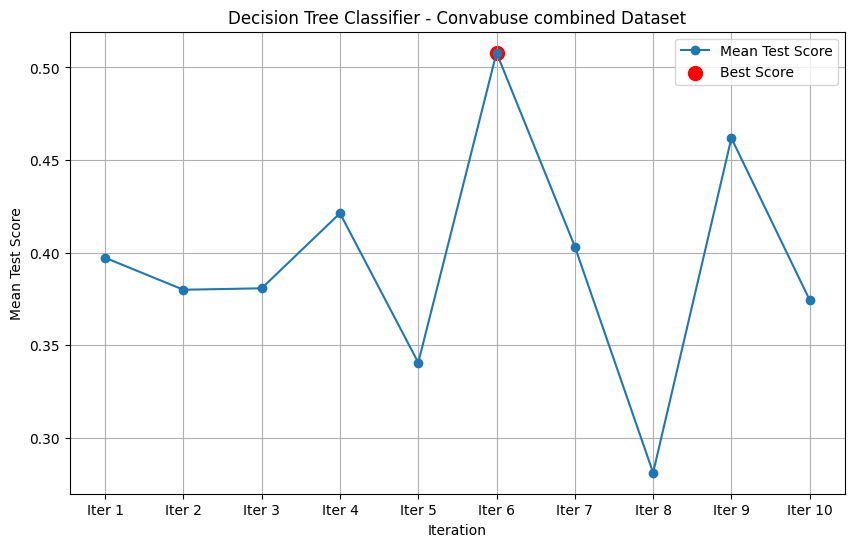

Convabuse combined Decision Tree Classifier:
Best Parameters: {'dt_classifier__min_samples_split': 404, 'dt_classifier__min_samples_leaf': 202, 'dt_classifier__max_depth': 8, 'dt_classifier__criterion': 'gini'}
Accuracy: 0.5283
F1 Score: 0.5260


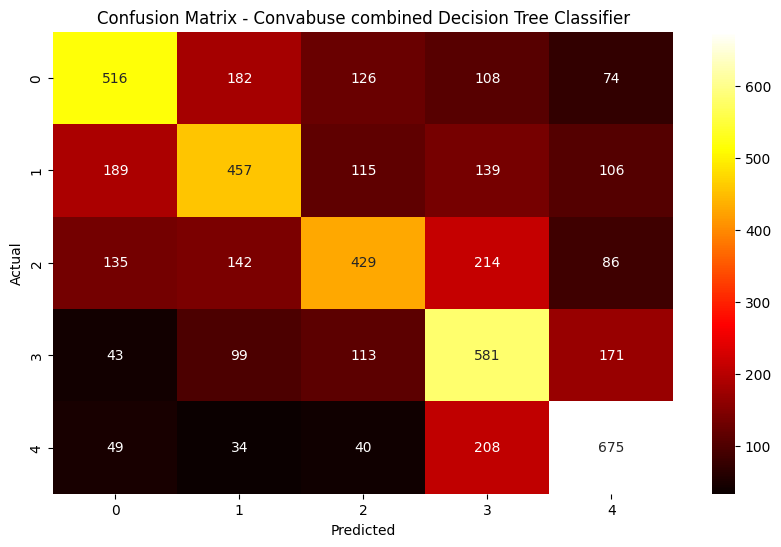

Classification Report for Convabuse combined Decision Tree Classifier:
              precision    recall  f1-score   support

           0       0.55      0.51      0.53      1006
           1       0.50      0.45      0.48      1006
           2       0.52      0.43      0.47      1006
           3       0.46      0.58      0.51      1007
           4       0.61      0.67      0.64      1006

    accuracy                           0.53      5031
   macro avg       0.53      0.53      0.53      5031
weighted avg       0.53      0.53      0.53      5031

Unsorted Feature Importances for Convabuse combined Decision Tree Classifier:
{0: np.float64(0.0), 1: np.float64(0.0), 2: np.float64(0.0), 3: np.float64(0.0), 4: np.float64(0.013194086374618838), 5: np.float64(0.0), 6: np.float64(0.0), 7: np.float64(0.011384915504657273), 8: np.float64(0.0), 9: np.float64(0.0), 10: np.float64(0.00784016792171045), 11: np.float64(0.0), 12: np.float64(0.0), 13: np.float64(0.0), 14: np.float64(0.0201634707

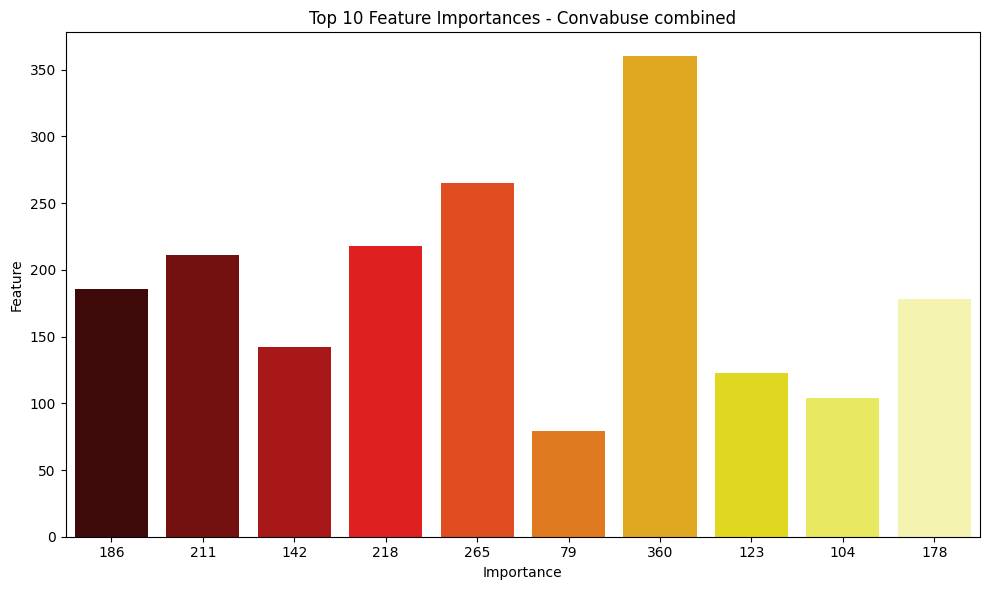

Top 10 Feature Importances for Convabuse combined Decision Tree Classifier:
{186: np.float64(0.02760831633465277), 211: np.float64(0.02873308945014592), 142: np.float64(0.032592464697599945), 218: np.float64(0.035947037675294495), 265: np.float64(0.03640377714075558), 79: np.float64(0.037441390941147366), 360: np.float64(0.04767856260826101), 123: np.float64(0.05020670943540014), 104: np.float64(0.07192499827067628), 178: np.float64(0.1010013896811788)}


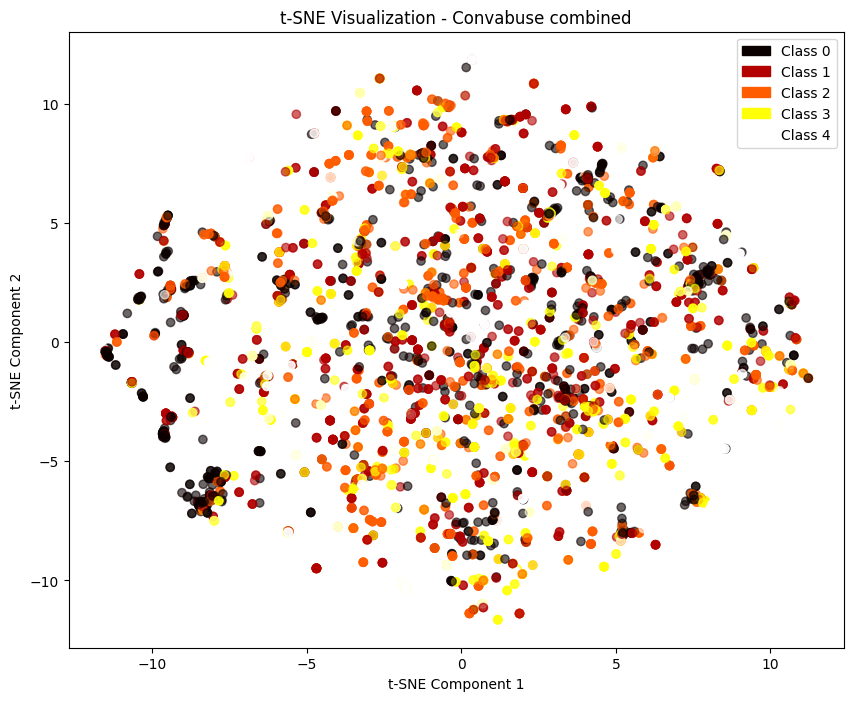

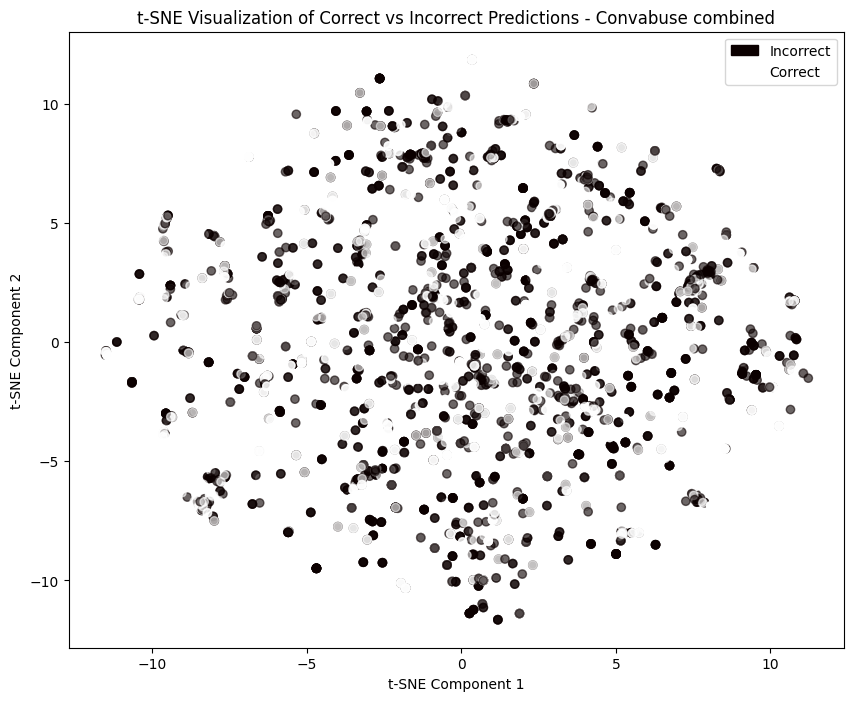

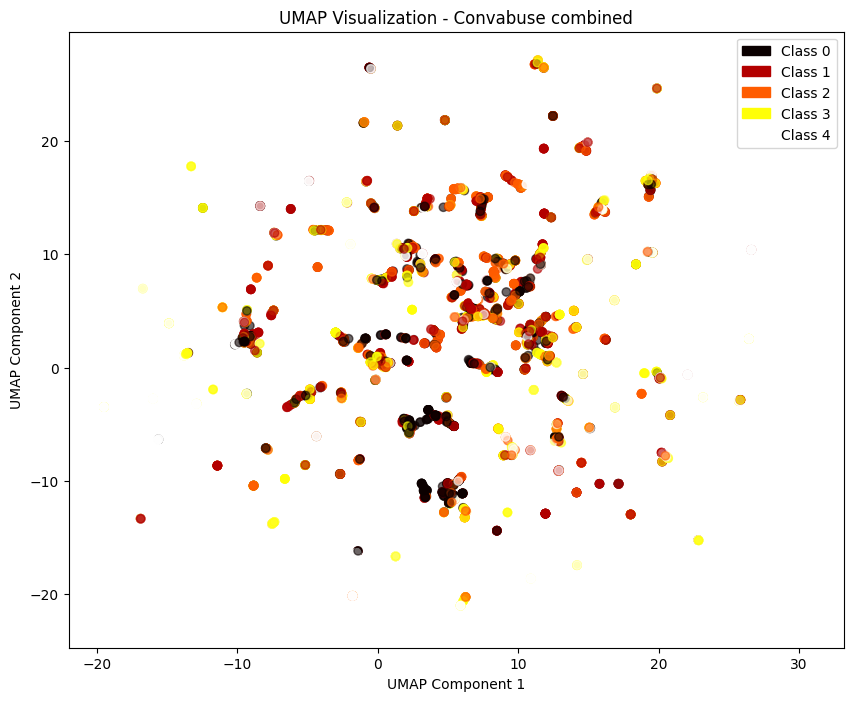

[('Decision Tree',
  'Convabuse combined',
  'NA',
  'NA',
  0.528324388789505,
  0.5259767241783131,
  0.0,
  {'dt_classifier__min_samples_split': 404,
   'dt_classifier__min_samples_leaf': 202,
   'dt_classifier__max_depth': 8,
   'dt_classifier__criterion': 'gini'},
  {0: np.float64(0.0),
   1: np.float64(0.0),
   2: np.float64(0.0),
   3: np.float64(0.0),
   4: np.float64(0.013194086374618838),
   5: np.float64(0.0),
   6: np.float64(0.0),
   7: np.float64(0.011384915504657273),
   8: np.float64(0.0),
   9: np.float64(0.0),
   10: np.float64(0.00784016792171045),
   11: np.float64(0.0),
   12: np.float64(0.0),
   13: np.float64(0.0),
   14: np.float64(0.02016347079479973),
   15: np.float64(0.008494793651039145),
   16: np.float64(0.0),
   17: np.float64(0.0),
   18: np.float64(0.0),
   19: np.float64(0.010467146824967577),
   20: np.float64(0.0),
   21: np.float64(0.0),
   22: np.float64(0.0),
   23: np.float64(0.0),
   24: np.float64(0.0),
   25: np.float64(0.0),
   26: np.float6

In [19]:
dt_classifier_model(convabuse_X_train, convabuse_y_train, convabuse_X_test, convabuse_y_test, "Convabuse combined")
dt_classification_results_list

Best parameters for Convabuse prev_agent Decision Tree Classifier: {'dt_classifier__min_samples_split': 404, 'dt_classifier__min_samples_leaf': 202, 'dt_classifier__max_depth': 8, 'dt_classifier__criterion': 'gini'}
Best score for Convabuse prev_agent Decision Tree Classifier: 0.33308470913648547
Time taken for Convabuse prev_agent Decision Tree Classifier Randomized Search: 54.18269228935242


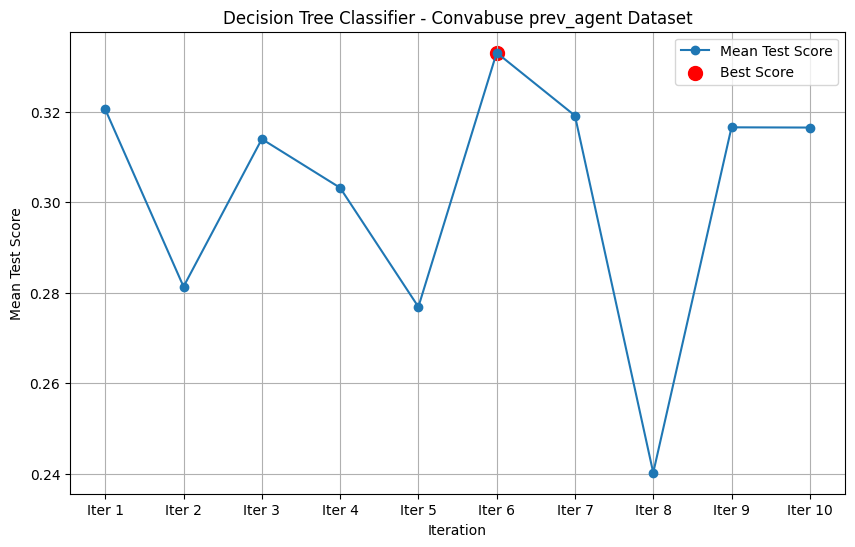

Convabuse prev_agent Decision Tree Classifier:
Best Parameters: {'dt_classifier__min_samples_split': 404, 'dt_classifier__min_samples_leaf': 202, 'dt_classifier__max_depth': 8, 'dt_classifier__criterion': 'gini'}
Accuracy: 0.3331
F1 Score: 0.3285


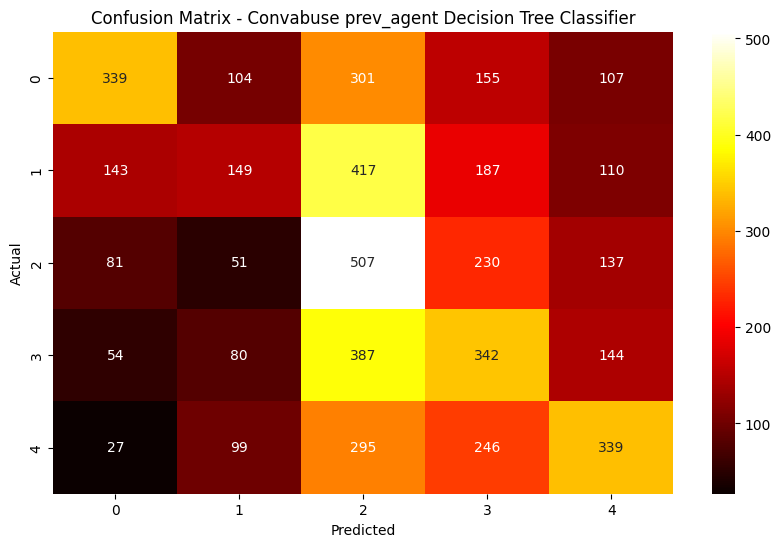

Classification Report for Convabuse prev_agent Decision Tree Classifier:
              precision    recall  f1-score   support

           0       0.53      0.34      0.41      1006
           1       0.31      0.15      0.20      1006
           2       0.27      0.50      0.35      1006
           3       0.29      0.34      0.32      1007
           4       0.41      0.34      0.37      1006

    accuracy                           0.33      5031
   macro avg       0.36      0.33      0.33      5031
weighted avg       0.36      0.33      0.33      5031

Unsorted Feature Importances for Convabuse prev_agent Decision Tree Classifier:
{0: np.float64(0.0), 1: np.float64(0.0), 2: np.float64(0.0), 3: np.float64(0.0), 4: np.float64(0.0), 5: np.float64(0.0), 6: np.float64(0.0), 7: np.float64(0.0), 8: np.float64(0.0), 9: np.float64(0.0), 10: np.float64(0.0), 11: np.float64(0.0), 12: np.float64(0.0), 13: np.float64(0.0), 14: np.float64(0.0), 15: np.float64(0.0), 16: np.float64(0.0), 17: np.flo

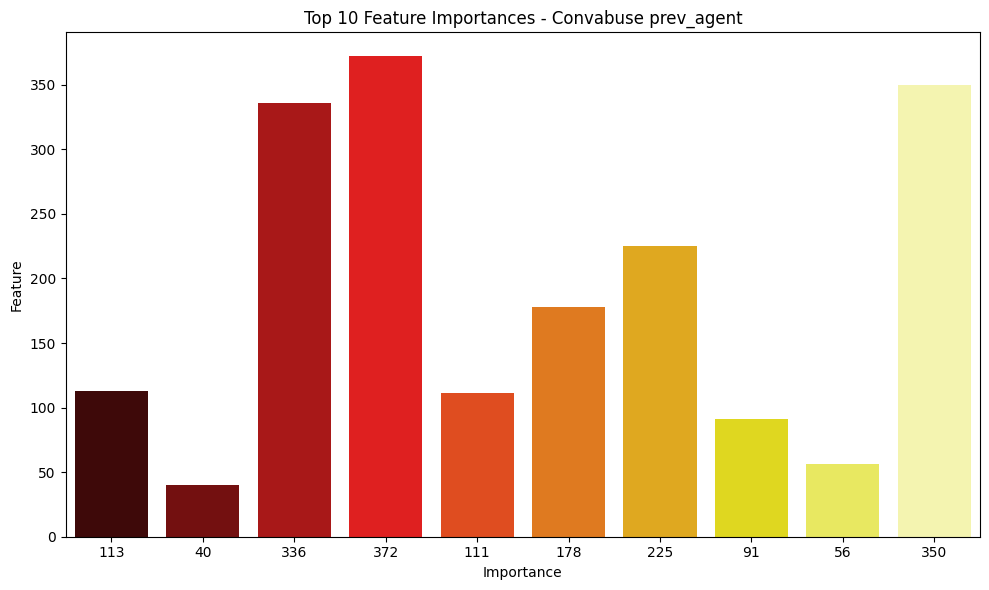

Top 10 Feature Importances for Convabuse prev_agent Decision Tree Classifier:
{113: np.float64(0.030039031058812168), 40: np.float64(0.03290744351041148), 336: np.float64(0.03771501871566609), 372: np.float64(0.03867045360421665), 111: np.float64(0.047618044340888364), 178: np.float64(0.05533334628522449), 225: np.float64(0.06280203552090985), 91: np.float64(0.0811032205439035), 56: np.float64(0.08732454952716046), 350: np.float64(0.27889523913984604)}


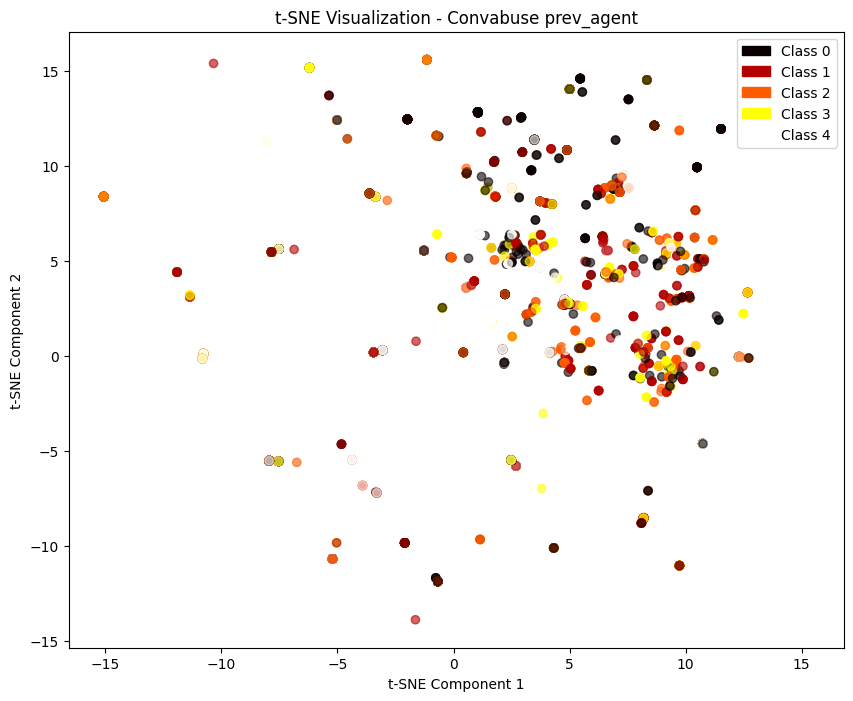

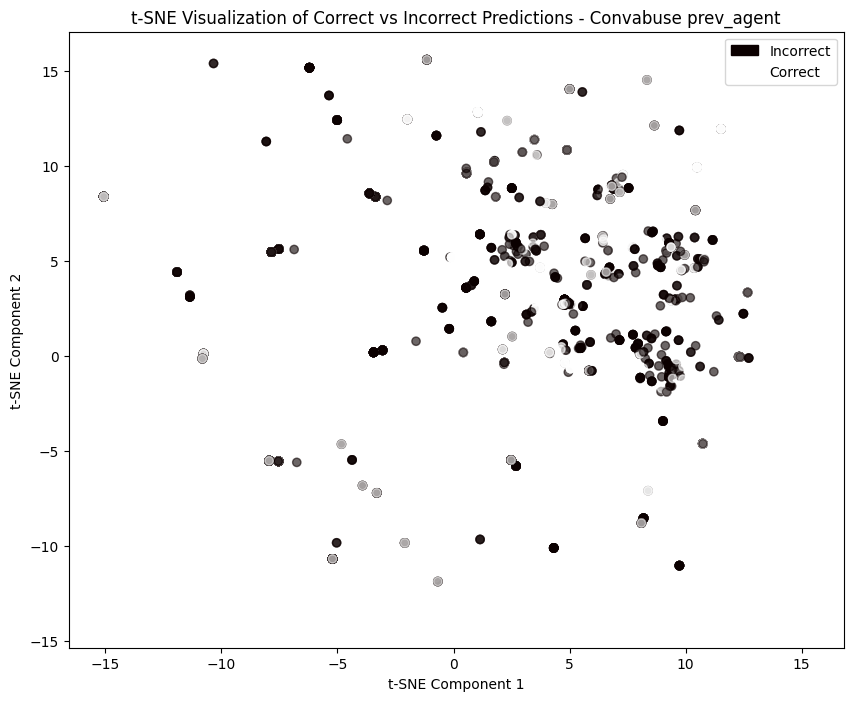

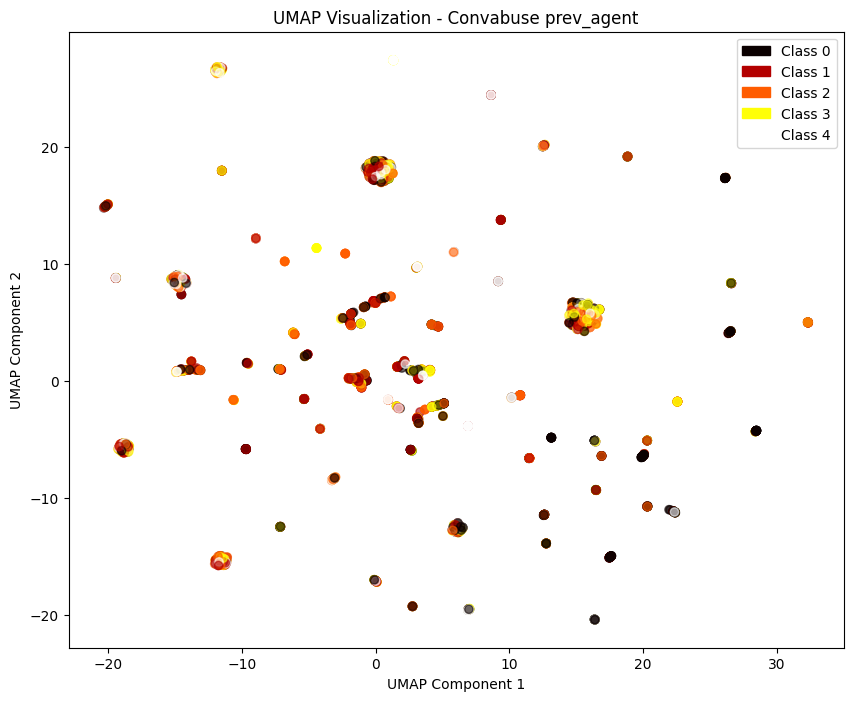

[('Decision Tree',
  'Convabuse combined',
  'NA',
  'NA',
  0.528324388789505,
  0.5259767241783131,
  0.0,
  {'dt_classifier__min_samples_split': 404,
   'dt_classifier__min_samples_leaf': 202,
   'dt_classifier__max_depth': 8,
   'dt_classifier__criterion': 'gini'},
  {0: np.float64(0.0),
   1: np.float64(0.0),
   2: np.float64(0.0),
   3: np.float64(0.0),
   4: np.float64(0.013194086374618838),
   5: np.float64(0.0),
   6: np.float64(0.0),
   7: np.float64(0.011384915504657273),
   8: np.float64(0.0),
   9: np.float64(0.0),
   10: np.float64(0.00784016792171045),
   11: np.float64(0.0),
   12: np.float64(0.0),
   13: np.float64(0.0),
   14: np.float64(0.02016347079479973),
   15: np.float64(0.008494793651039145),
   16: np.float64(0.0),
   17: np.float64(0.0),
   18: np.float64(0.0),
   19: np.float64(0.010467146824967577),
   20: np.float64(0.0),
   21: np.float64(0.0),
   22: np.float64(0.0),
   23: np.float64(0.0),
   24: np.float64(0.0),
   25: np.float64(0.0),
   26: np.float6

In [20]:
dt_classifier_model(convabuse_prev_agent_X_train, convabuse_prev_agent_y_train, convabuse_prev_agent_X_test, convabuse_prev_agent_y_test, "Convabuse prev_agent")
dt_classification_results_list

Best parameters for Convabuse prev_user Decision Tree Classifier: {'dt_classifier__min_samples_split': 404, 'dt_classifier__min_samples_leaf': 202, 'dt_classifier__max_depth': 8, 'dt_classifier__criterion': 'gini'}
Best score for Convabuse prev_user Decision Tree Classifier: 0.3908779126483336
Time taken for Convabuse prev_user Decision Tree Classifier Randomized Search: 101.33881735801697


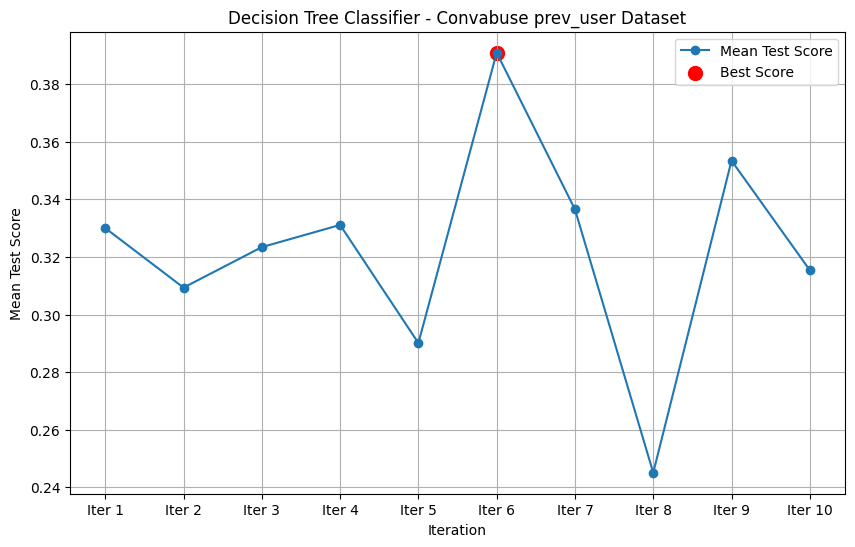

Convabuse prev_user Decision Tree Classifier:
Best Parameters: {'dt_classifier__min_samples_split': 404, 'dt_classifier__min_samples_leaf': 202, 'dt_classifier__max_depth': 8, 'dt_classifier__criterion': 'gini'}
Accuracy: 0.4301
F1 Score: 0.4247


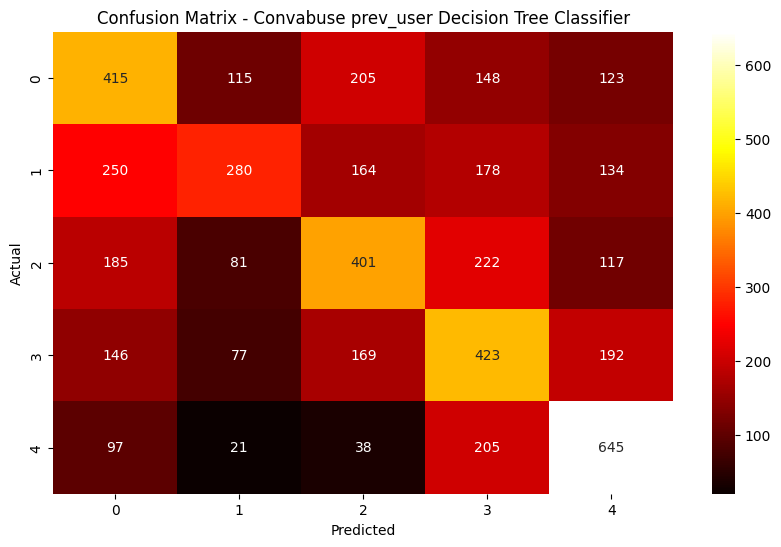

Classification Report for Convabuse prev_user Decision Tree Classifier:
              precision    recall  f1-score   support

           0       0.38      0.41      0.40      1006
           1       0.49      0.28      0.35      1006
           2       0.41      0.40      0.40      1006
           3       0.36      0.42      0.39      1007
           4       0.53      0.64      0.58      1006

    accuracy                           0.43      5031
   macro avg       0.43      0.43      0.42      5031
weighted avg       0.43      0.43      0.42      5031

Unsorted Feature Importances for Convabuse prev_user Decision Tree Classifier:
{0: np.float64(0.0), 1: np.float64(0.0), 2: np.float64(0.0), 3: np.float64(0.0), 4: np.float64(0.0), 5: np.float64(0.0), 6: np.float64(0.0), 7: np.float64(0.0), 8: np.float64(0.0), 9: np.float64(0.0), 10: np.float64(0.0), 11: np.float64(0.0), 12: np.float64(0.0), 13: np.float64(0.0), 14: np.float64(0.0), 15: np.float64(0.0), 16: np.float64(0.0), 17: np.float

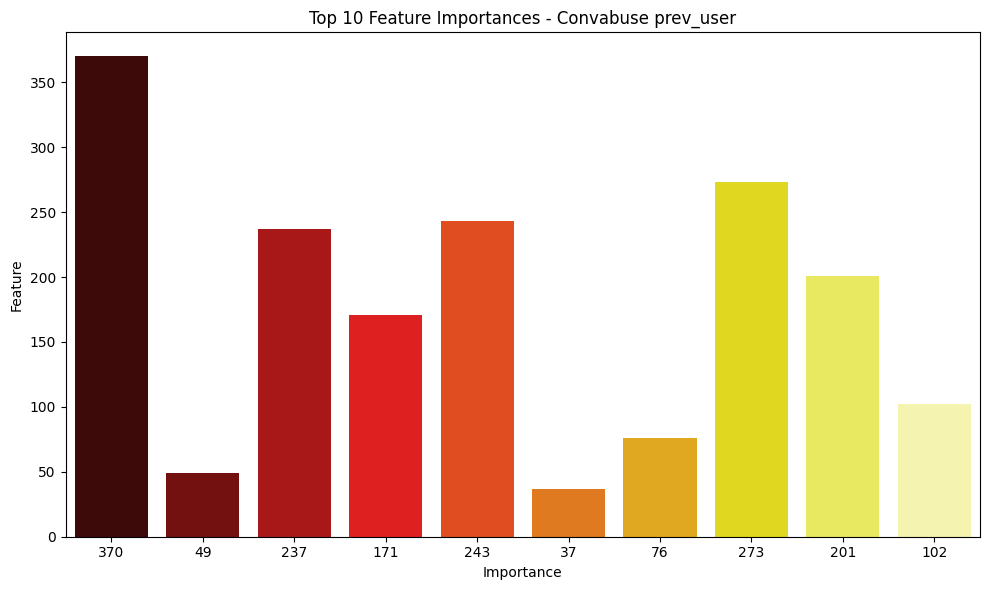

Top 10 Feature Importances for Convabuse prev_user Decision Tree Classifier:
{370: np.float64(0.031056335384902305), 49: np.float64(0.036208011727038414), 237: np.float64(0.039415105540256574), 171: np.float64(0.04052475283804271), 243: np.float64(0.04145293926684449), 37: np.float64(0.04234645996225856), 76: np.float64(0.045708163305012296), 273: np.float64(0.04969998901122607), 201: np.float64(0.05807912044288599), 102: np.float64(0.05969558764406108)}


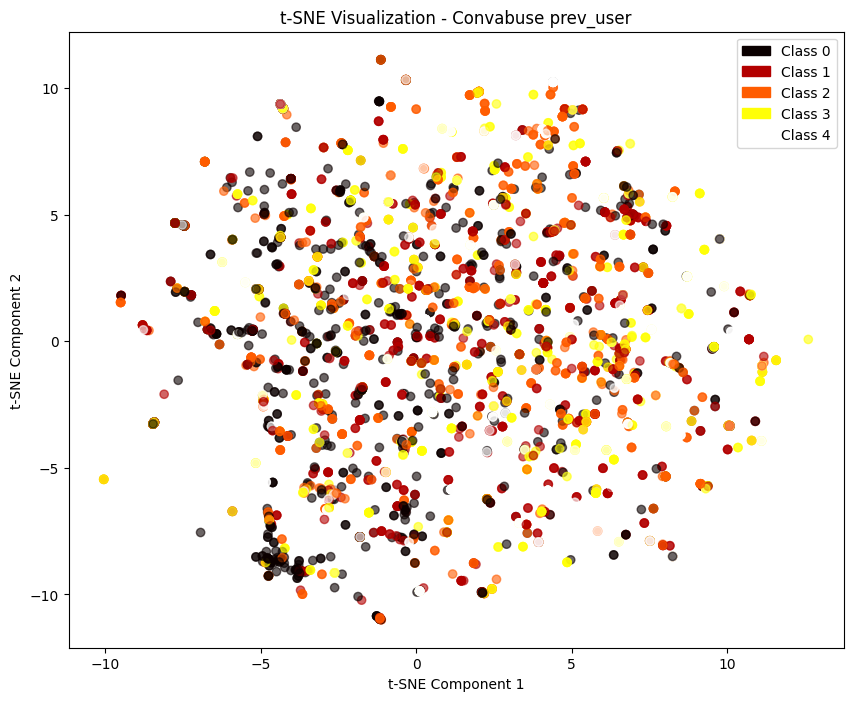

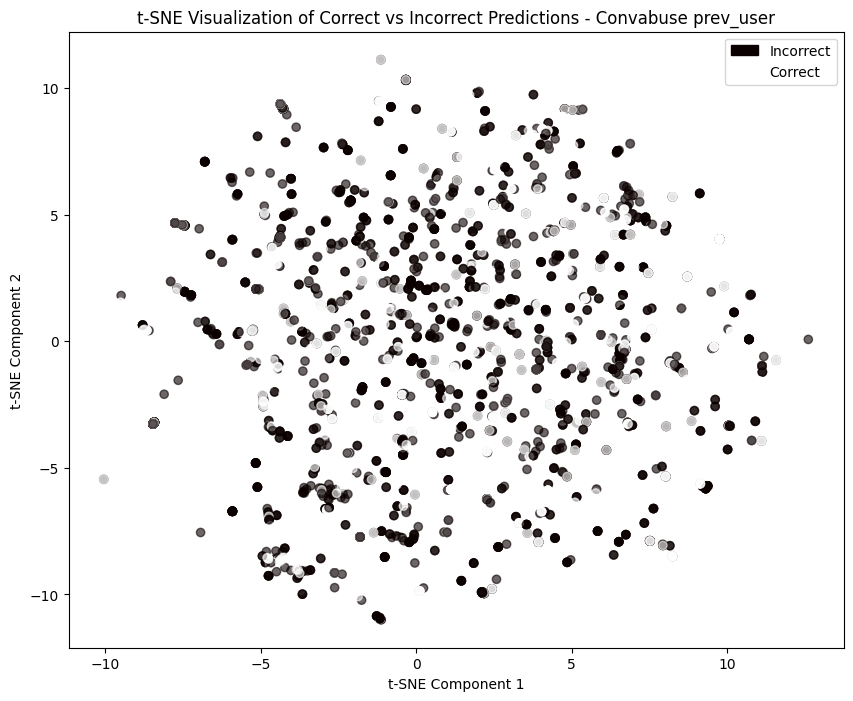

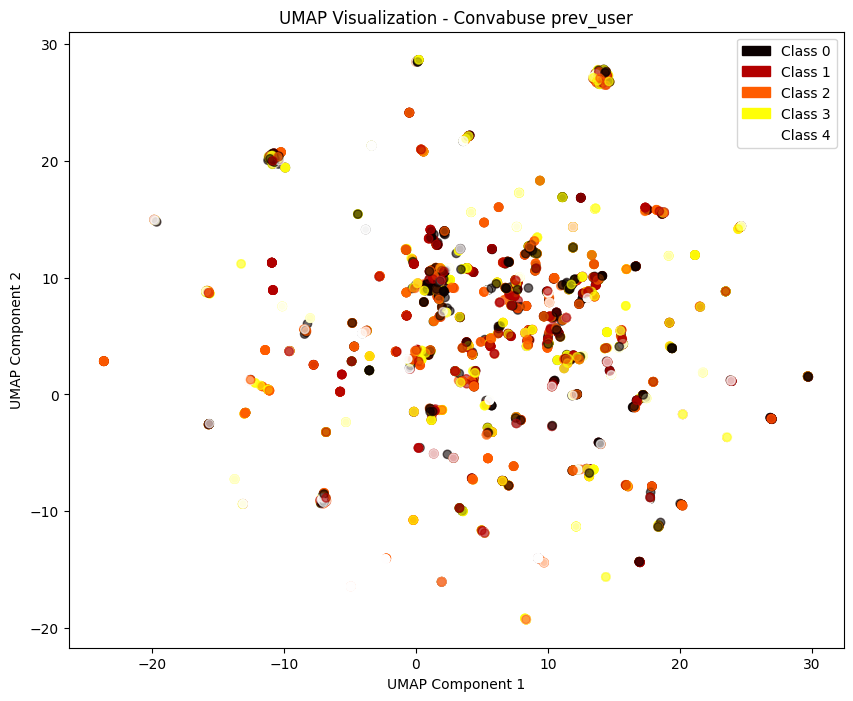

[('Decision Tree',
  'Convabuse combined',
  'NA',
  'NA',
  0.528324388789505,
  0.5259767241783131,
  0.0,
  {'dt_classifier__min_samples_split': 404,
   'dt_classifier__min_samples_leaf': 202,
   'dt_classifier__max_depth': 8,
   'dt_classifier__criterion': 'gini'},
  {0: np.float64(0.0),
   1: np.float64(0.0),
   2: np.float64(0.0),
   3: np.float64(0.0),
   4: np.float64(0.013194086374618838),
   5: np.float64(0.0),
   6: np.float64(0.0),
   7: np.float64(0.011384915504657273),
   8: np.float64(0.0),
   9: np.float64(0.0),
   10: np.float64(0.00784016792171045),
   11: np.float64(0.0),
   12: np.float64(0.0),
   13: np.float64(0.0),
   14: np.float64(0.02016347079479973),
   15: np.float64(0.008494793651039145),
   16: np.float64(0.0),
   17: np.float64(0.0),
   18: np.float64(0.0),
   19: np.float64(0.010467146824967577),
   20: np.float64(0.0),
   21: np.float64(0.0),
   22: np.float64(0.0),
   23: np.float64(0.0),
   24: np.float64(0.0),
   25: np.float64(0.0),
   26: np.float6

In [21]:
dt_classifier_model(convabuse_prev_user_X_train, convabuse_prev_user_y_train, convabuse_prev_user_X_test, convabuse_prev_user_y_test, "Convabuse prev_user")
dt_classification_results_list

Best parameters for Convabuse agent Decision Tree Classifier: {'dt_classifier__min_samples_split': 404, 'dt_classifier__min_samples_leaf': 202, 'dt_classifier__max_depth': 8, 'dt_classifier__criterion': 'gini'}
Best score for Convabuse agent Decision Tree Classifier: 0.34322242939876274
Time taken for Convabuse agent Decision Tree Classifier Randomized Search: 49.58032178878784


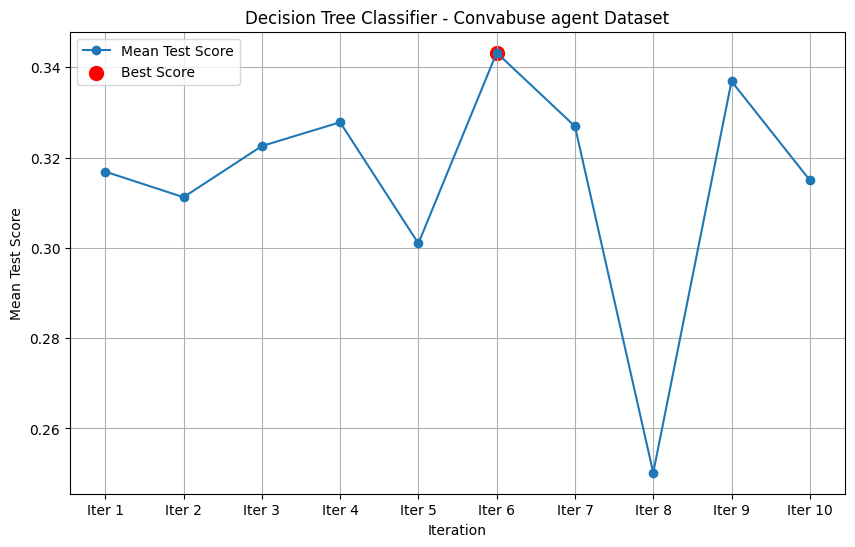

Convabuse agent Decision Tree Classifier:
Best Parameters: {'dt_classifier__min_samples_split': 404, 'dt_classifier__min_samples_leaf': 202, 'dt_classifier__max_depth': 8, 'dt_classifier__criterion': 'gini'}
Accuracy: 0.3502
F1 Score: 0.3530


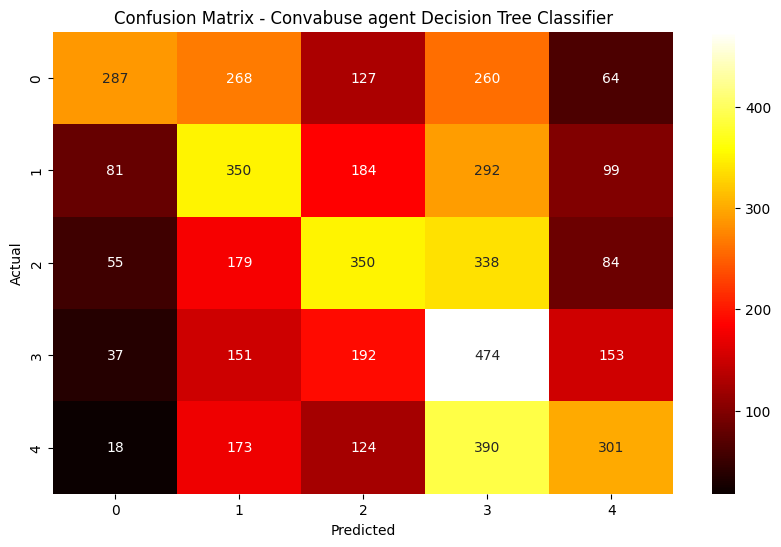

Classification Report for Convabuse agent Decision Tree Classifier:
              precision    recall  f1-score   support

           0       0.60      0.29      0.39      1006
           1       0.31      0.35      0.33      1006
           2       0.36      0.35      0.35      1006
           3       0.27      0.47      0.34      1007
           4       0.43      0.30      0.35      1006

    accuracy                           0.35      5031
   macro avg       0.39      0.35      0.35      5031
weighted avg       0.39      0.35      0.35      5031

Unsorted Feature Importances for Convabuse agent Decision Tree Classifier:
{0: np.float64(0.0), 1: np.float64(0.0), 2: np.float64(0.0), 3: np.float64(0.0), 4: np.float64(0.0), 5: np.float64(0.0), 6: np.float64(0.0), 7: np.float64(0.0), 8: np.float64(0.0), 9: np.float64(0.0), 10: np.float64(0.0), 11: np.float64(0.0), 12: np.float64(0.0), 13: np.float64(0.0), 14: np.float64(0.0), 15: np.float64(0.0), 16: np.float64(0.0), 17: np.float64(0.0),

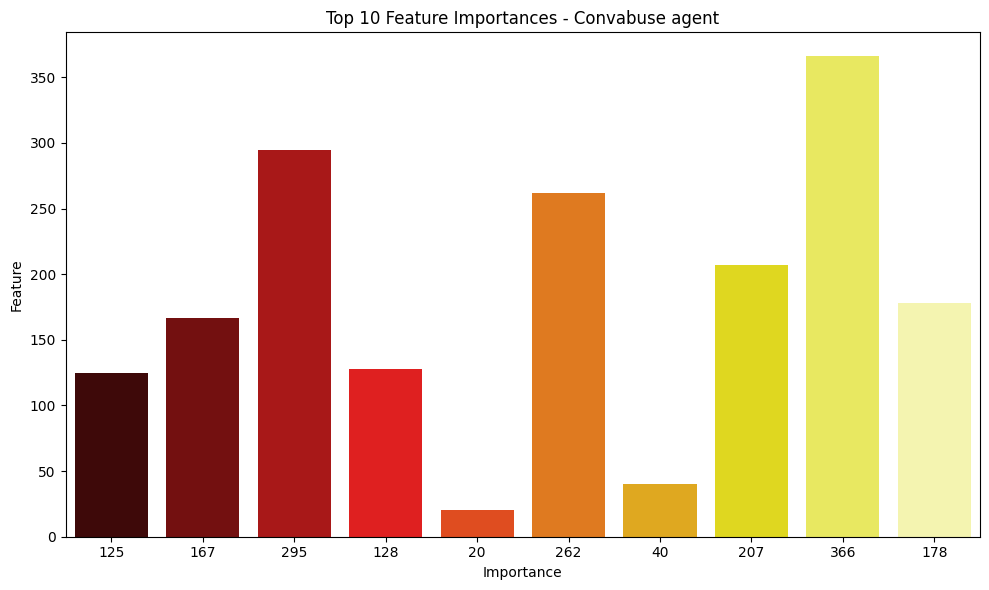

Top 10 Feature Importances for Convabuse agent Decision Tree Classifier:
{125: np.float64(0.02992268867269864), 167: np.float64(0.0321202819504755), 295: np.float64(0.03610248611811671), 128: np.float64(0.04028665698400129), 20: np.float64(0.04321135672499337), 262: np.float64(0.04922165652665413), 40: np.float64(0.07158123674755226), 207: np.float64(0.07856713944644207), 366: np.float64(0.10612037360612299), 178: np.float64(0.28015069440196366)}


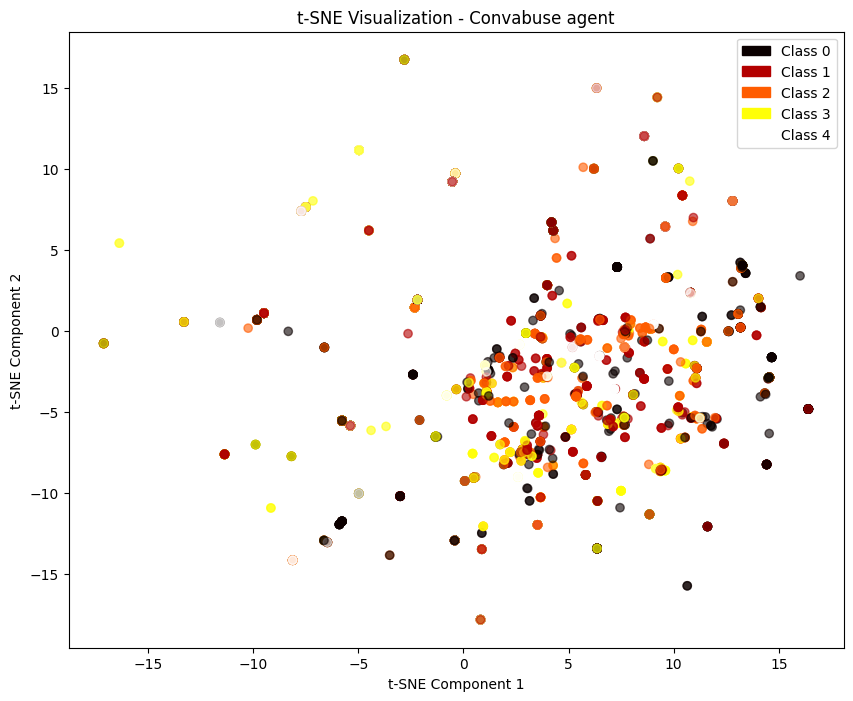

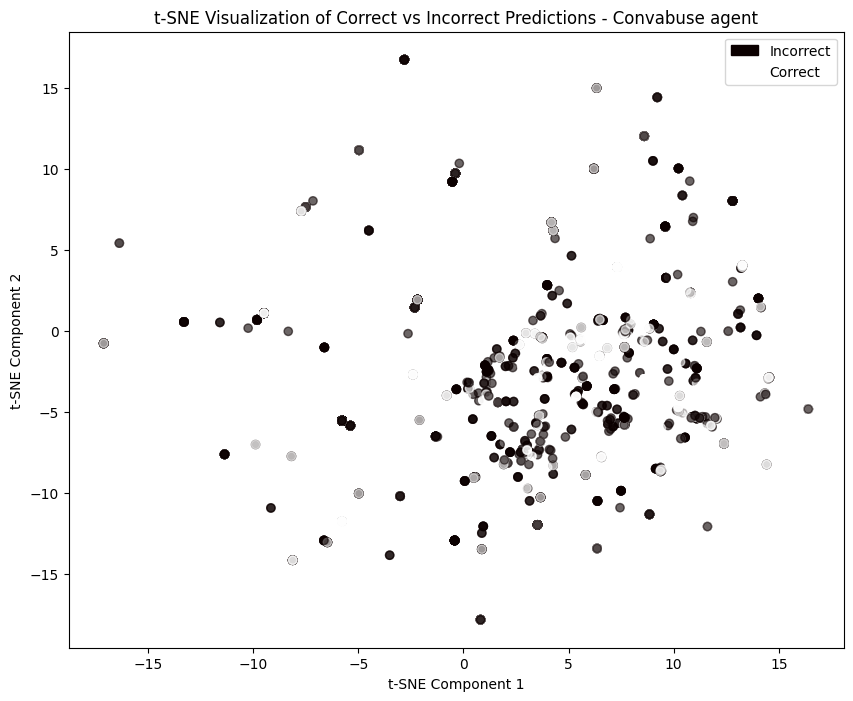

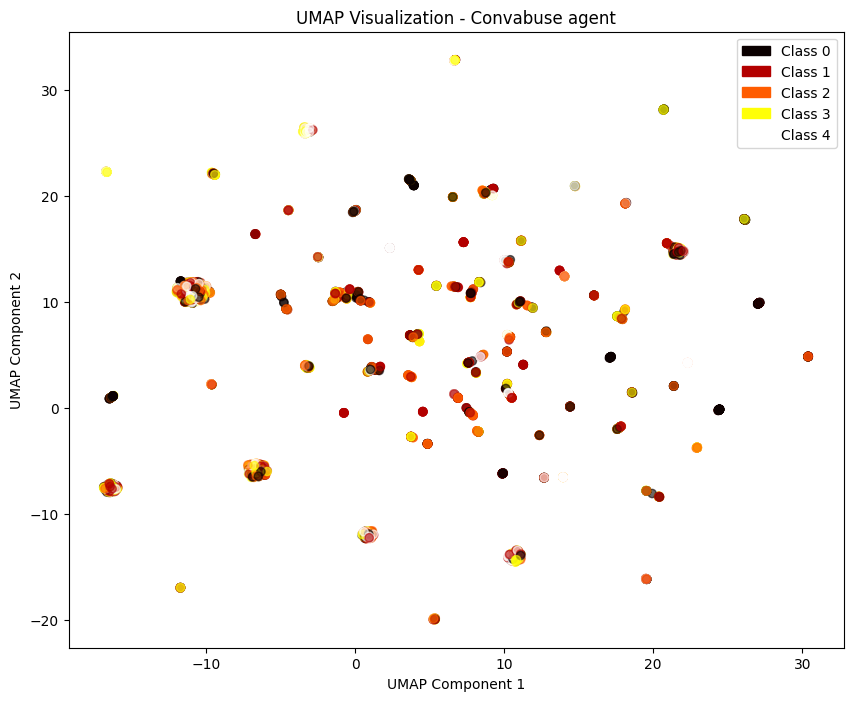

[('Decision Tree',
  'Convabuse combined',
  'NA',
  'NA',
  0.528324388789505,
  0.5259767241783131,
  0.0,
  {'dt_classifier__min_samples_split': 404,
   'dt_classifier__min_samples_leaf': 202,
   'dt_classifier__max_depth': 8,
   'dt_classifier__criterion': 'gini'},
  {0: np.float64(0.0),
   1: np.float64(0.0),
   2: np.float64(0.0),
   3: np.float64(0.0),
   4: np.float64(0.013194086374618838),
   5: np.float64(0.0),
   6: np.float64(0.0),
   7: np.float64(0.011384915504657273),
   8: np.float64(0.0),
   9: np.float64(0.0),
   10: np.float64(0.00784016792171045),
   11: np.float64(0.0),
   12: np.float64(0.0),
   13: np.float64(0.0),
   14: np.float64(0.02016347079479973),
   15: np.float64(0.008494793651039145),
   16: np.float64(0.0),
   17: np.float64(0.0),
   18: np.float64(0.0),
   19: np.float64(0.010467146824967577),
   20: np.float64(0.0),
   21: np.float64(0.0),
   22: np.float64(0.0),
   23: np.float64(0.0),
   24: np.float64(0.0),
   25: np.float64(0.0),
   26: np.float6

In [22]:
dt_classifier_model(convabuse_agent_X_train, convabuse_agent_y_train, convabuse_agent_X_test, convabuse_agent_y_test, "Convabuse agent")
dt_classification_results_list

Best parameters for Convabuse user Decision Tree Classifier: {'dt_classifier__min_samples_split': 404, 'dt_classifier__min_samples_leaf': 202, 'dt_classifier__max_depth': 8, 'dt_classifier__criterion': 'gini'}
Best score for Convabuse user Decision Tree Classifier: 0.5342873566057074
Time taken for Convabuse user Decision Tree Classifier Randomized Search: 97.61997318267822


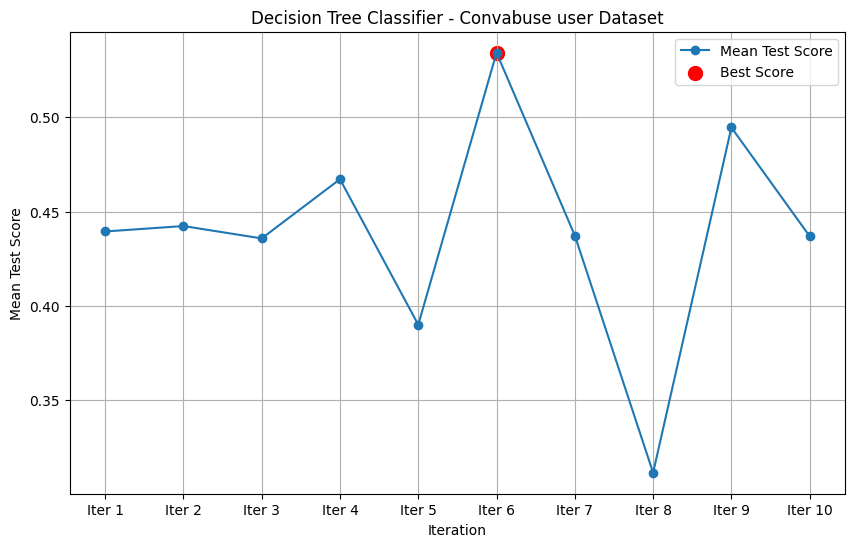

Convabuse user Decision Tree Classifier:
Best Parameters: {'dt_classifier__min_samples_split': 404, 'dt_classifier__min_samples_leaf': 202, 'dt_classifier__max_depth': 8, 'dt_classifier__criterion': 'gini'}
Accuracy: 0.5601
F1 Score: 0.5570


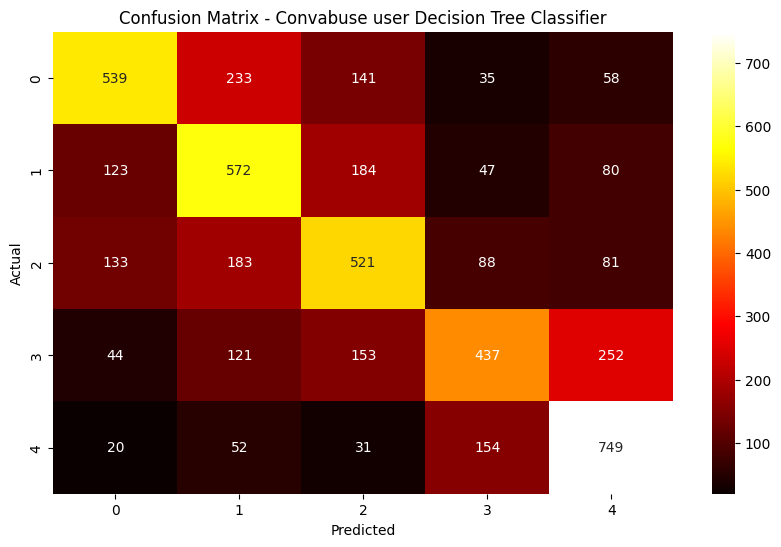

Classification Report for Convabuse user Decision Tree Classifier:
              precision    recall  f1-score   support

           0       0.63      0.54      0.58      1006
           1       0.49      0.57      0.53      1006
           2       0.51      0.52      0.51      1006
           3       0.57      0.43      0.49      1007
           4       0.61      0.74      0.67      1006

    accuracy                           0.56      5031
   macro avg       0.56      0.56      0.56      5031
weighted avg       0.56      0.56      0.56      5031

Unsorted Feature Importances for Convabuse user Decision Tree Classifier:
{0: np.float64(0.0), 1: np.float64(0.0), 2: np.float64(0.0), 3: np.float64(0.0), 4: np.float64(0.0), 5: np.float64(0.0), 6: np.float64(0.002506530204909131), 7: np.float64(0.0), 8: np.float64(0.0), 9: np.float64(0.011390001763288185), 10: np.float64(0.0), 11: np.float64(0.0), 12: np.float64(0.0), 13: np.float64(0.0), 14: np.float64(0.0), 15: np.float64(0.0353917341554

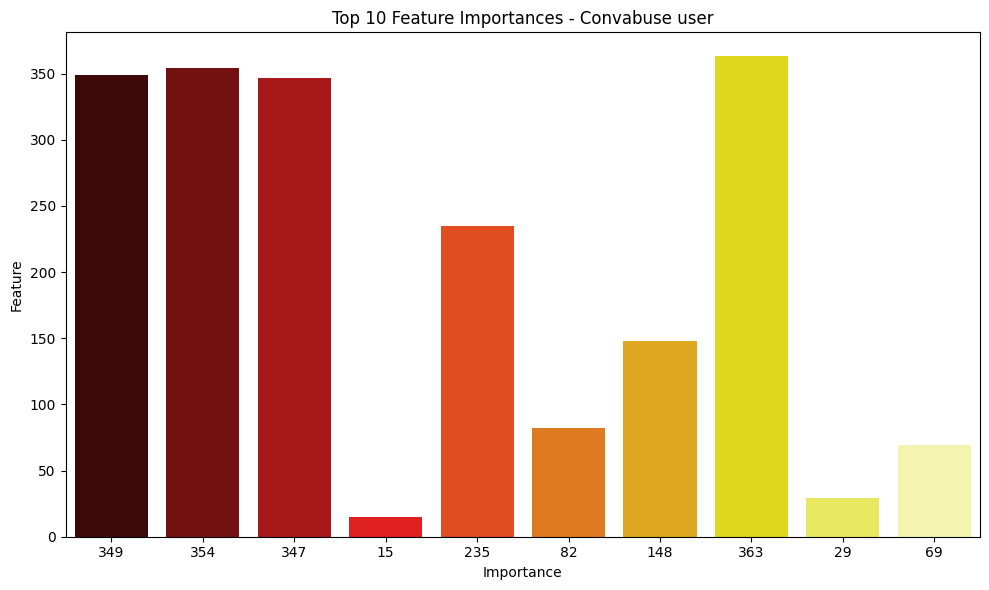

Top 10 Feature Importances for Convabuse user Decision Tree Classifier:
{349: np.float64(0.021045551275896513), 354: np.float64(0.02278295520008795), 347: np.float64(0.023307064518451756), 15: np.float64(0.03539173415545322), 235: np.float64(0.035653089154996646), 82: np.float64(0.03635490673480385), 148: np.float64(0.05116953690315445), 363: np.float64(0.05471161173823141), 29: np.float64(0.08139063692753762), 69: np.float64(0.15041727661559812)}


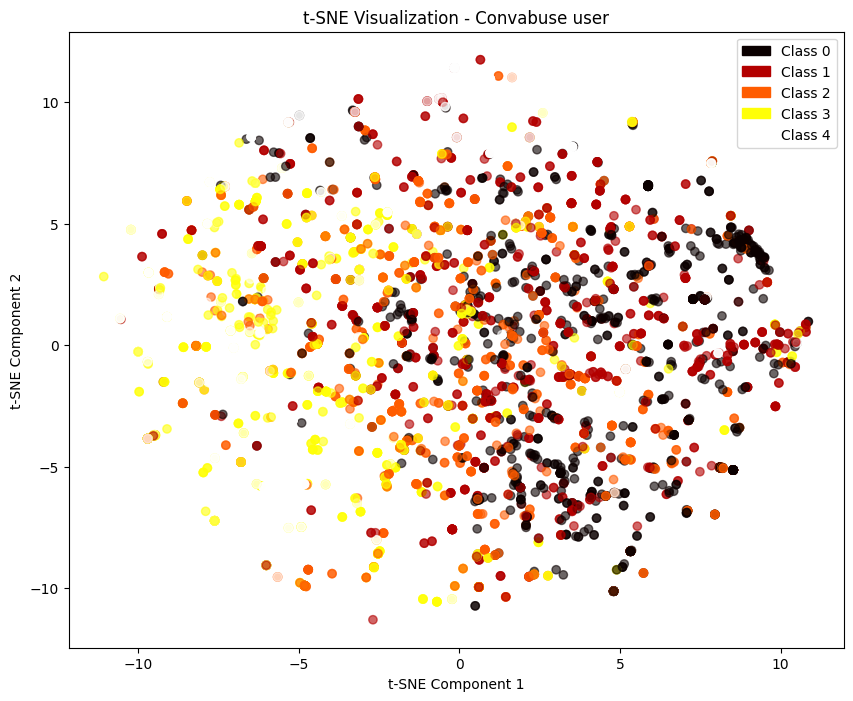

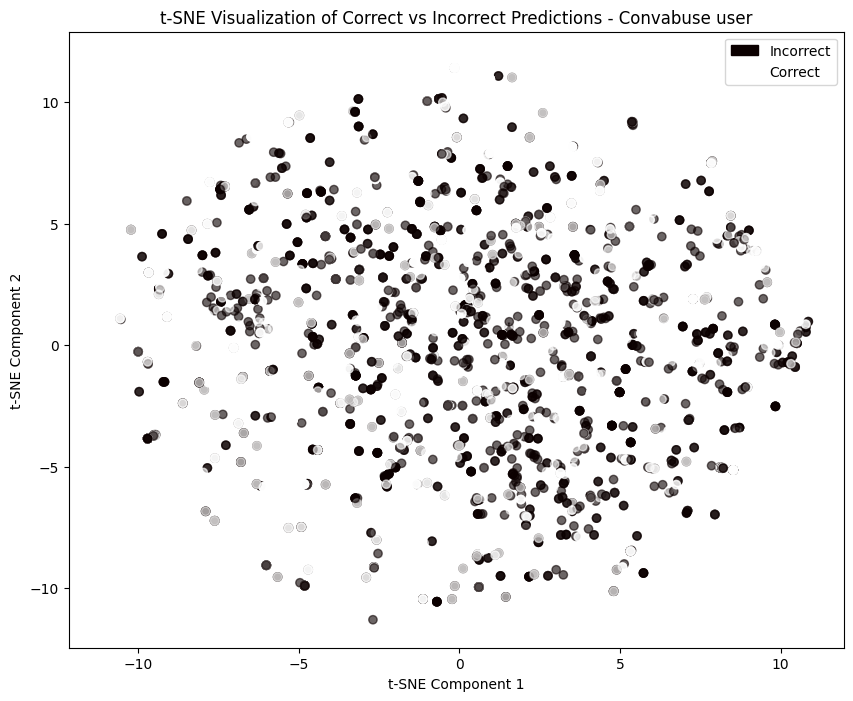

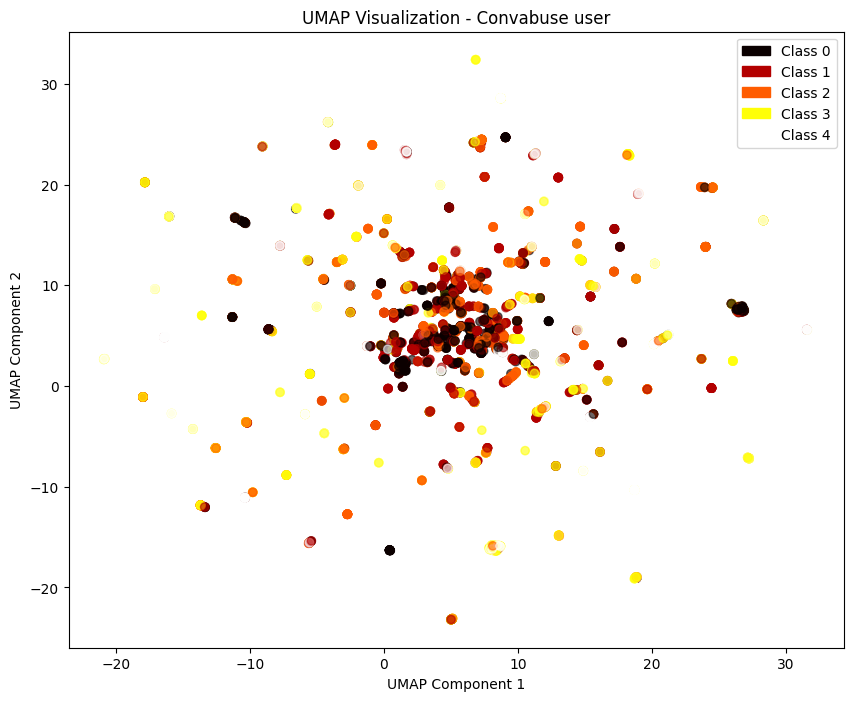

[('Decision Tree',
  'Convabuse combined',
  'NA',
  'NA',
  0.528324388789505,
  0.5259767241783131,
  0.0,
  {'dt_classifier__min_samples_split': 404,
   'dt_classifier__min_samples_leaf': 202,
   'dt_classifier__max_depth': 8,
   'dt_classifier__criterion': 'gini'},
  {0: np.float64(0.0),
   1: np.float64(0.0),
   2: np.float64(0.0),
   3: np.float64(0.0),
   4: np.float64(0.013194086374618838),
   5: np.float64(0.0),
   6: np.float64(0.0),
   7: np.float64(0.011384915504657273),
   8: np.float64(0.0),
   9: np.float64(0.0),
   10: np.float64(0.00784016792171045),
   11: np.float64(0.0),
   12: np.float64(0.0),
   13: np.float64(0.0),
   14: np.float64(0.02016347079479973),
   15: np.float64(0.008494793651039145),
   16: np.float64(0.0),
   17: np.float64(0.0),
   18: np.float64(0.0),
   19: np.float64(0.010467146824967577),
   20: np.float64(0.0),
   21: np.float64(0.0),
   22: np.float64(0.0),
   23: np.float64(0.0),
   24: np.float64(0.0),
   25: np.float64(0.0),
   26: np.float6

In [23]:
dt_classifier_model(convabuse_user_X_train, convabuse_user_y_train, convabuse_user_X_test, convabuse_user_y_test, "Convabuse user")
dt_classification_results_list

## Dynamically Generated Hate Speech Decision Tree

Best parameters for Dynamically Generated Hate Speech target Decision Tree Classifier: {'dt_classifier__min_samples_split': 912, 'dt_classifier__min_samples_leaf': 1216, 'dt_classifier__max_depth': 9, 'dt_classifier__criterion': 'entropy'}
Best score for Dynamically Generated Hate Speech target Decision Tree Classifier: 0.7720593080724878
Time taken for Dynamically Generated Hate Speech target Decision Tree Classifier Randomized Search: 403.8166651725769


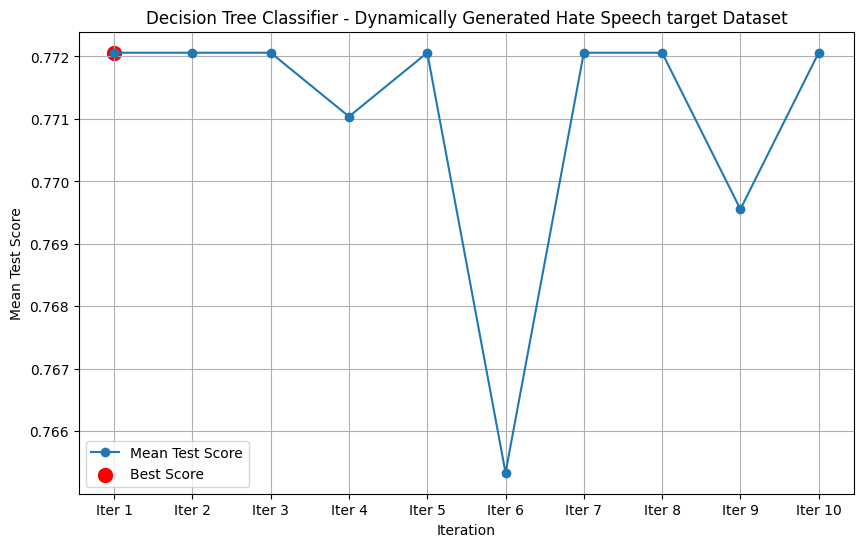

Dynamically Generated Hate Speech target Decision Tree Classifier:
Best Parameters: {'dt_classifier__min_samples_split': 912, 'dt_classifier__min_samples_leaf': 1216, 'dt_classifier__max_depth': 9, 'dt_classifier__criterion': 'entropy'}
Accuracy: 0.7721
F1 Score: 0.6729


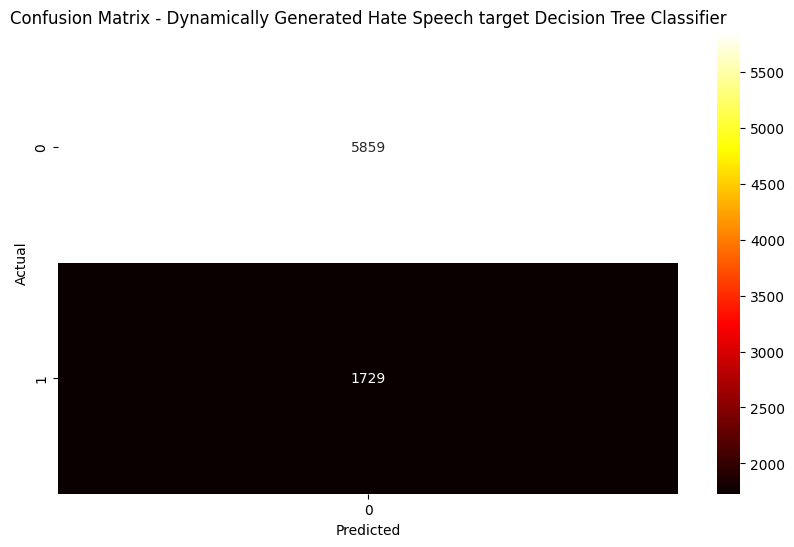

Classification Report for Dynamically Generated Hate Speech target Decision Tree Classifier:
              precision    recall  f1-score   support

           0       0.77      1.00      0.87      5859
           1       0.00      0.00      0.00      1729

    accuracy                           0.77      7588
   macro avg       0.39      0.50      0.44      7588
weighted avg       0.60      0.77      0.67      7588

Unsorted Feature Importances for Dynamically Generated Hate Speech target Decision Tree Classifier:
{0: np.float64(0.0), 1: np.float64(0.0), 2: np.float64(0.0), 3: np.float64(0.0), 4: np.float64(0.0), 5: np.float64(0.0), 6: np.float64(0.0), 7: np.float64(0.0), 8: np.float64(0.0), 9: np.float64(0.0), 10: np.float64(0.0), 11: np.float64(0.0), 12: np.float64(0.0), 13: np.float64(0.0), 14: np.float64(0.0), 15: np.float64(0.0), 16: np.float64(0.0), 17: np.float64(0.0), 18: np.float64(0.0), 19: np.float64(0.0), 20: np.float64(0.0), 21: np.float64(0.0), 22: np.float64(0.0), 23: np

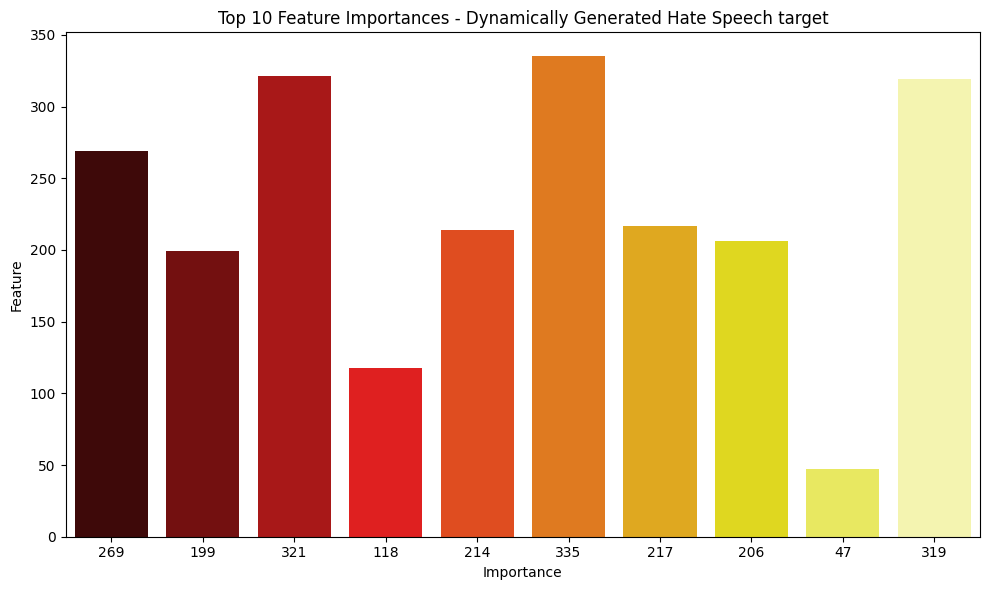

Top 10 Feature Importances for Dynamically Generated Hate Speech target Decision Tree Classifier:
{269: np.float64(0.01757073933194338), 199: np.float64(0.01938432762271026), 321: np.float64(0.01963173157720616), 118: np.float64(0.020242579140241943), 214: np.float64(0.022117136959460073), 335: np.float64(0.028197438859618958), 217: np.float64(0.03205273538251292), 206: np.float64(0.053565027740088686), 47: np.float64(0.10038634494142716), 319: np.float64(0.6032297617120318)}


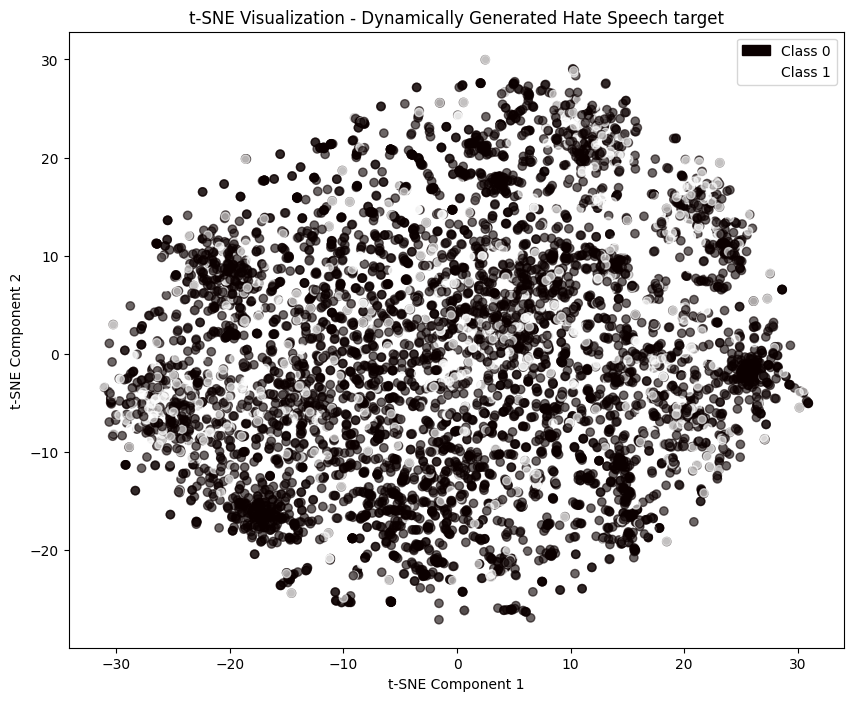

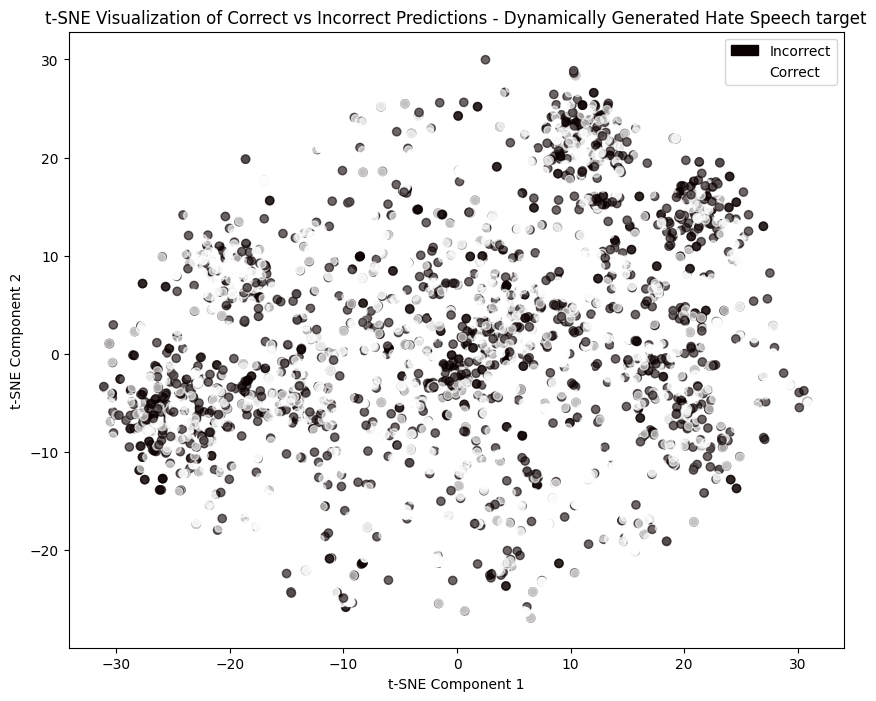

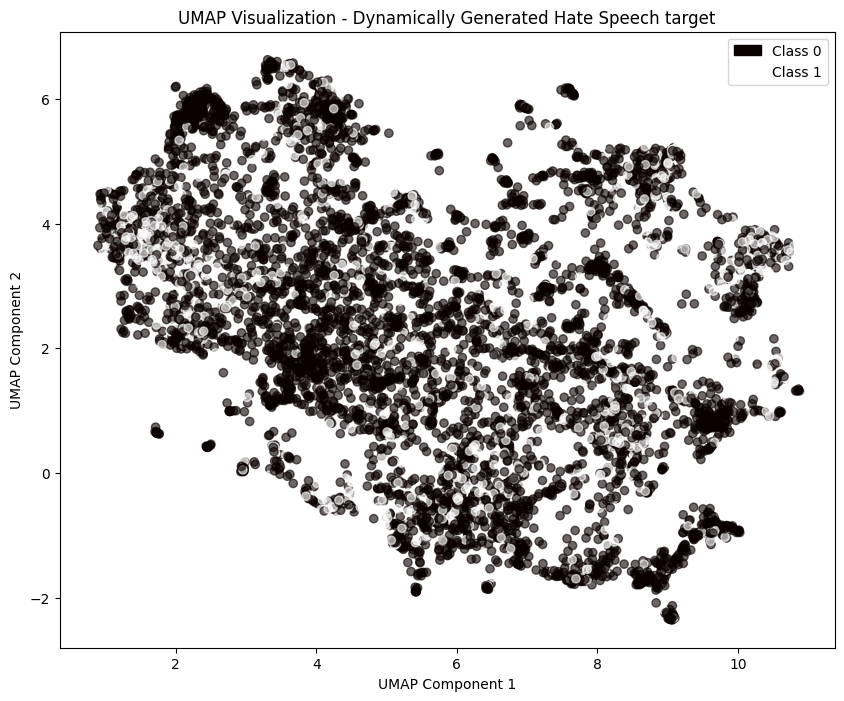

[('Decision Tree',
  'Convabuse combined',
  'NA',
  'NA',
  0.528324388789505,
  0.5259767241783131,
  0.0,
  {'dt_classifier__min_samples_split': 404,
   'dt_classifier__min_samples_leaf': 202,
   'dt_classifier__max_depth': 8,
   'dt_classifier__criterion': 'gini'},
  {0: np.float64(0.0),
   1: np.float64(0.0),
   2: np.float64(0.0),
   3: np.float64(0.0),
   4: np.float64(0.013194086374618838),
   5: np.float64(0.0),
   6: np.float64(0.0),
   7: np.float64(0.011384915504657273),
   8: np.float64(0.0),
   9: np.float64(0.0),
   10: np.float64(0.00784016792171045),
   11: np.float64(0.0),
   12: np.float64(0.0),
   13: np.float64(0.0),
   14: np.float64(0.02016347079479973),
   15: np.float64(0.008494793651039145),
   16: np.float64(0.0),
   17: np.float64(0.0),
   18: np.float64(0.0),
   19: np.float64(0.010467146824967577),
   20: np.float64(0.0),
   21: np.float64(0.0),
   22: np.float64(0.0),
   23: np.float64(0.0),
   24: np.float64(0.0),
   25: np.float64(0.0),
   26: np.float6

In [24]:
dt_classifier_model(dghs_target_X_train, dghs_target_y_train, dghs_target_X_test, dghs_target_y_test, "Dynamically Generated Hate Speech target")
dt_classification_results_list

Best parameters for Dynamically Generated Hate Speech label Decision Tree Classifier: {'dt_classifier__min_samples_split': 608, 'dt_classifier__min_samples_leaf': 304, 'dt_classifier__max_depth': 8, 'dt_classifier__criterion': 'gini'}
Best score for Dynamically Generated Hate Speech label Decision Tree Classifier: 0.6130148270181219
Time taken for Dynamically Generated Hate Speech label Decision Tree Classifier Randomized Search: 412.6259307861328


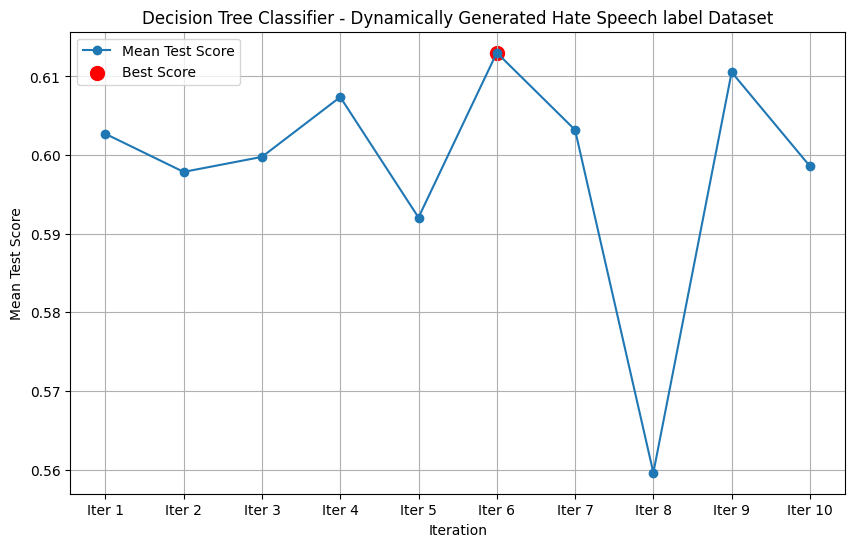

Dynamically Generated Hate Speech label Decision Tree Classifier:
Best Parameters: {'dt_classifier__min_samples_split': 608, 'dt_classifier__min_samples_leaf': 304, 'dt_classifier__max_depth': 8, 'dt_classifier__criterion': 'gini'}
Accuracy: 0.6170
F1 Score: 0.6162


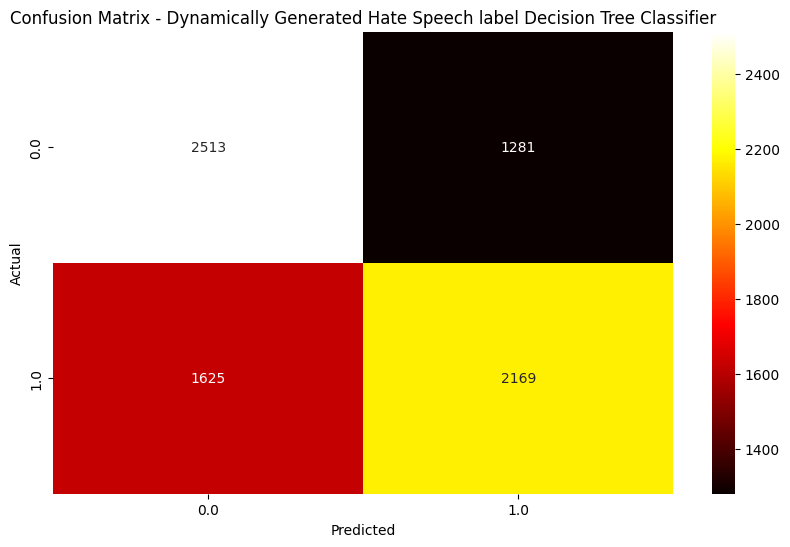

Classification Report for Dynamically Generated Hate Speech label Decision Tree Classifier:
              precision    recall  f1-score   support

         0.0       0.61      0.66      0.63      3794
         1.0       0.63      0.57      0.60      3794

    accuracy                           0.62      7588
   macro avg       0.62      0.62      0.62      7588
weighted avg       0.62      0.62      0.62      7588

Unsorted Feature Importances for Dynamically Generated Hate Speech label Decision Tree Classifier:
{0: np.float64(0.0), 1: np.float64(0.005703995332370348), 2: np.float64(0.0), 3: np.float64(0.0), 4: np.float64(0.0), 5: np.float64(0.0), 6: np.float64(0.0), 7: np.float64(0.08102137773222964), 8: np.float64(0.0), 9: np.float64(0.0), 10: np.float64(0.004023880112726215), 11: np.float64(0.0), 12: np.float64(0.0), 13: np.float64(0.0), 14: np.float64(0.0), 15: np.float64(0.0), 16: np.float64(0.0), 17: np.float64(0.0), 18: np.float64(0.0), 19: np.float64(0.0), 20: np.float64(0.0), 

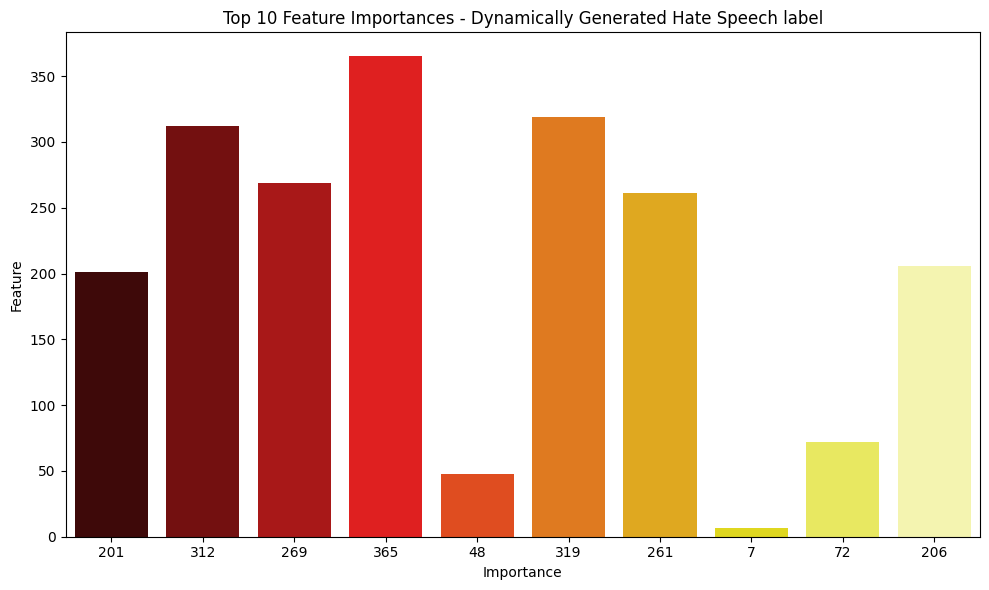

Top 10 Feature Importances for Dynamically Generated Hate Speech label Decision Tree Classifier:
{201: np.float64(0.020665967250452364), 312: np.float64(0.02523499817896482), 269: np.float64(0.030027129035636608), 365: np.float64(0.05126651379171074), 48: np.float64(0.05414276791185572), 319: np.float64(0.07422235084297414), 261: np.float64(0.07502999259321178), 7: np.float64(0.08102137773222964), 72: np.float64(0.08768941536756858), 206: np.float64(0.15844739433107266)}


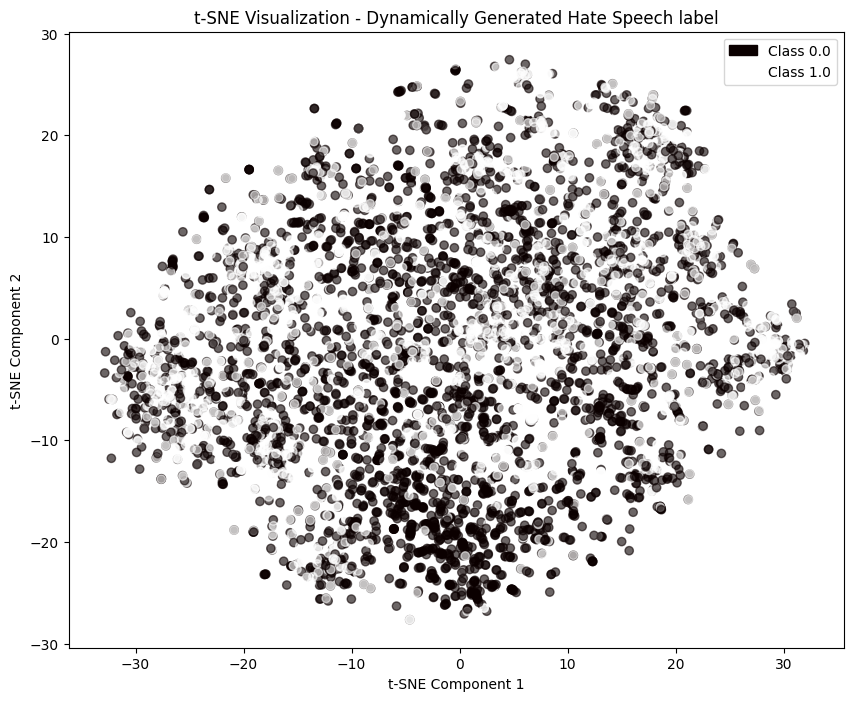

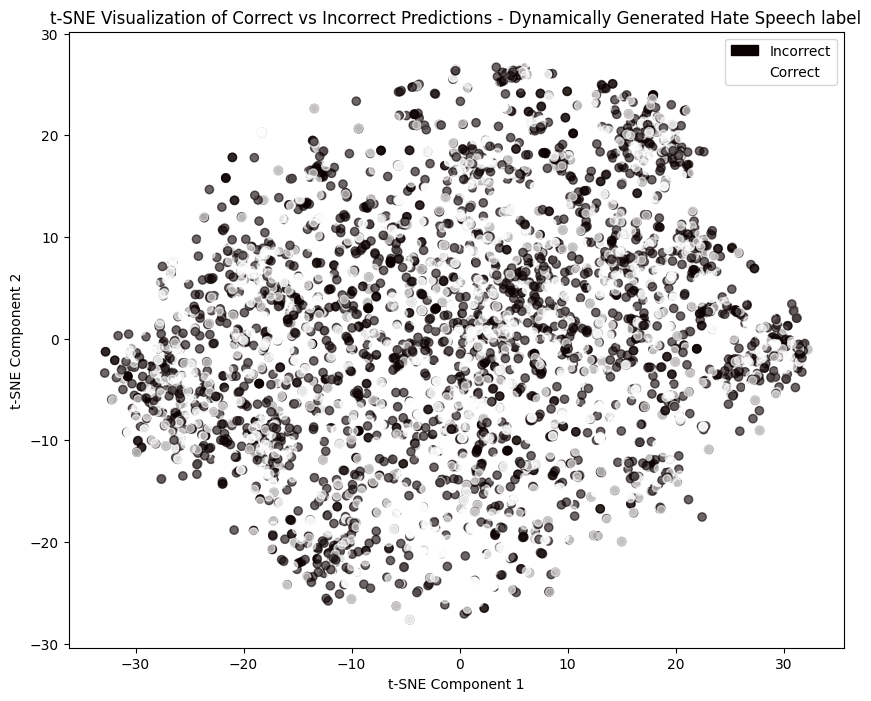

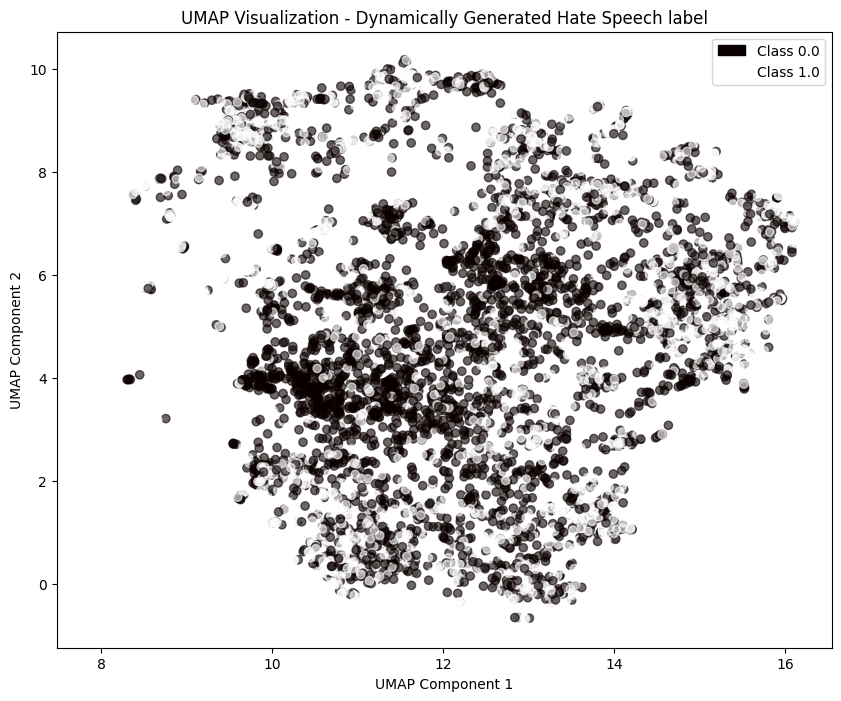

[('Decision Tree',
  'Convabuse combined',
  'NA',
  'NA',
  0.528324388789505,
  0.5259767241783131,
  0.0,
  {'dt_classifier__min_samples_split': 404,
   'dt_classifier__min_samples_leaf': 202,
   'dt_classifier__max_depth': 8,
   'dt_classifier__criterion': 'gini'},
  {0: np.float64(0.0),
   1: np.float64(0.0),
   2: np.float64(0.0),
   3: np.float64(0.0),
   4: np.float64(0.013194086374618838),
   5: np.float64(0.0),
   6: np.float64(0.0),
   7: np.float64(0.011384915504657273),
   8: np.float64(0.0),
   9: np.float64(0.0),
   10: np.float64(0.00784016792171045),
   11: np.float64(0.0),
   12: np.float64(0.0),
   13: np.float64(0.0),
   14: np.float64(0.02016347079479973),
   15: np.float64(0.008494793651039145),
   16: np.float64(0.0),
   17: np.float64(0.0),
   18: np.float64(0.0),
   19: np.float64(0.010467146824967577),
   20: np.float64(0.0),
   21: np.float64(0.0),
   22: np.float64(0.0),
   23: np.float64(0.0),
   24: np.float64(0.0),
   25: np.float64(0.0),
   26: np.float6

In [25]:
dt_classifier_model(dghs_label_X_train, dghs_label_y_train, dghs_label_X_test, dghs_label_y_test, "Dynamically Generated Hate Speech label")
dt_classification_results_list

## MLMA Hate Speech Decision Tree

Best parameters for MLMA Hate Speech Decision Tree Classifier: {'dt_classifier__min_samples_split': 455, 'dt_classifier__min_samples_leaf': 364, 'dt_classifier__max_depth': 1, 'dt_classifier__criterion': 'entropy'}
Best score for MLMA Hate Speech Decision Tree Classifier: 0.6768123962368566
Time taken for MLMA Hate Speech Decision Tree Classifier Randomized Search: 119.22852230072021


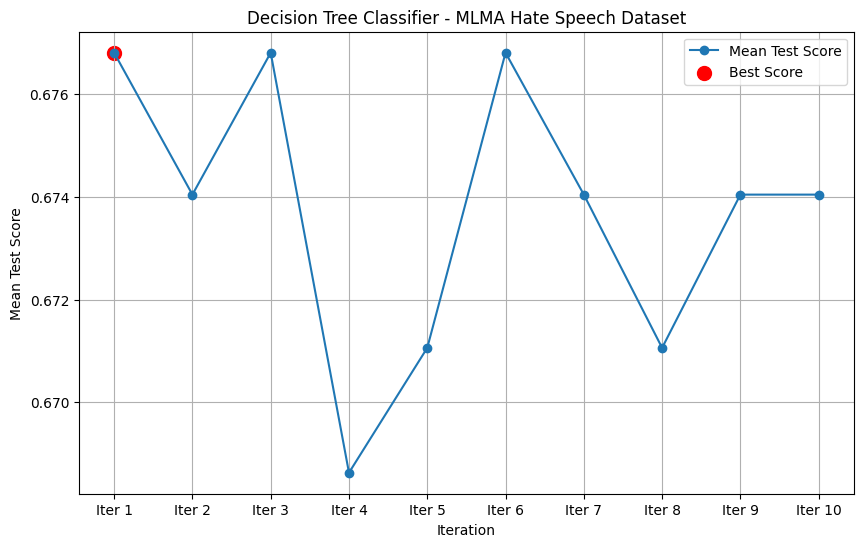

MLMA Hate Speech Decision Tree Classifier:
Best Parameters: {'dt_classifier__min_samples_split': 455, 'dt_classifier__min_samples_leaf': 364, 'dt_classifier__max_depth': 1, 'dt_classifier__criterion': 'entropy'}
Accuracy: 0.6768
F1 Score: 0.5464


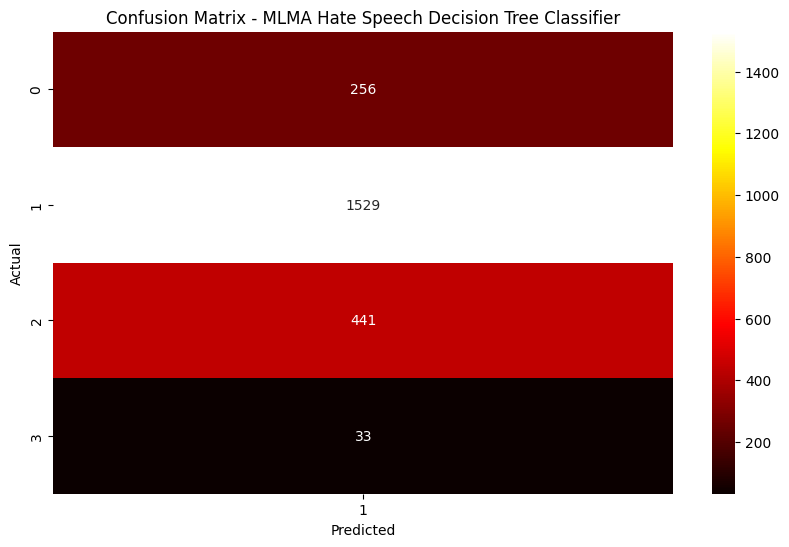

Classification Report for MLMA Hate Speech Decision Tree Classifier:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       256
           1       0.68      1.00      0.81      1529
           2       0.00      0.00      0.00       441
           3       0.00      0.00      0.00        33

    accuracy                           0.68      2259
   macro avg       0.17      0.25      0.20      2259
weighted avg       0.46      0.68      0.55      2259

Unsorted Feature Importances for MLMA Hate Speech Decision Tree Classifier:
{0: np.float64(0.0), 1: np.float64(0.0), 2: np.float64(0.0), 3: np.float64(0.0), 4: np.float64(0.0), 5: np.float64(0.0), 6: np.float64(0.0), 7: np.float64(0.0), 8: np.float64(0.0), 9: np.float64(0.0), 10: np.float64(0.0), 11: np.float64(0.0), 12: np.float64(0.0), 13: np.float64(0.0), 14: np.float64(0.0), 15: np.float64(0.0), 16: np.float64(0.0), 17: np.float64(0.0), 18: np.float64(0.0), 19: np.float64(0.0), 20: np.fl

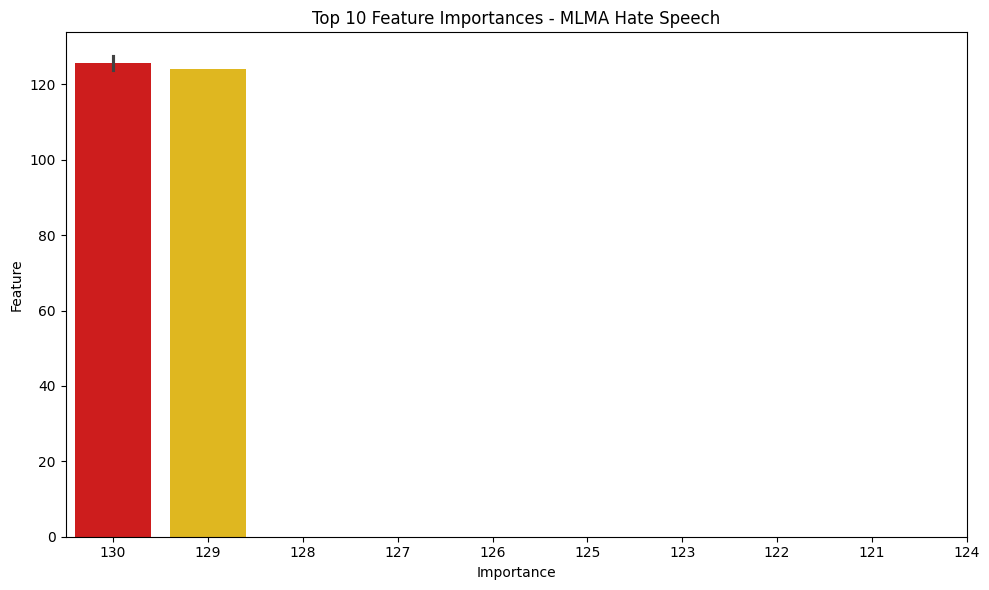

Top 10 Feature Importances for MLMA Hate Speech Decision Tree Classifier:
{130: np.float64(0.0), 129: np.float64(0.0), 128: np.float64(0.0), 127: np.float64(0.0), 126: np.float64(0.0), 125: np.float64(0.0), 123: np.float64(0.0), 122: np.float64(0.0), 121: np.float64(0.0), 124: np.float64(1.0)}


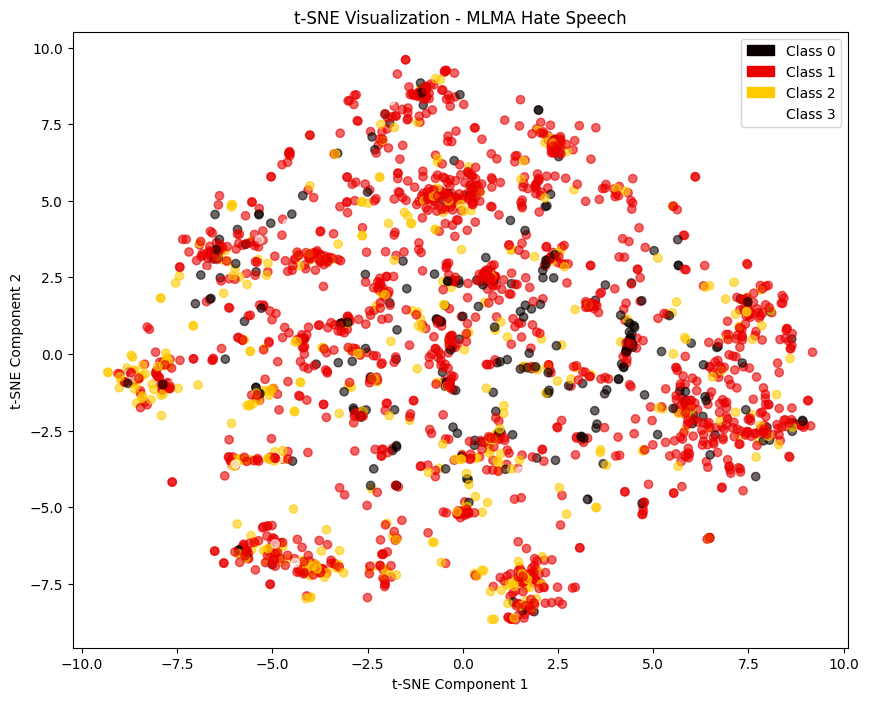

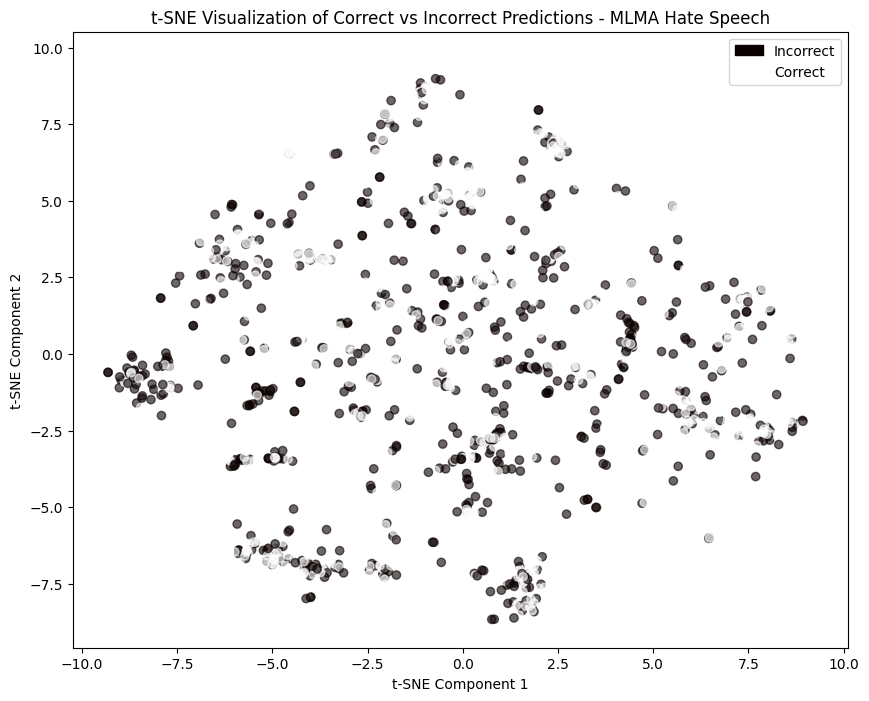

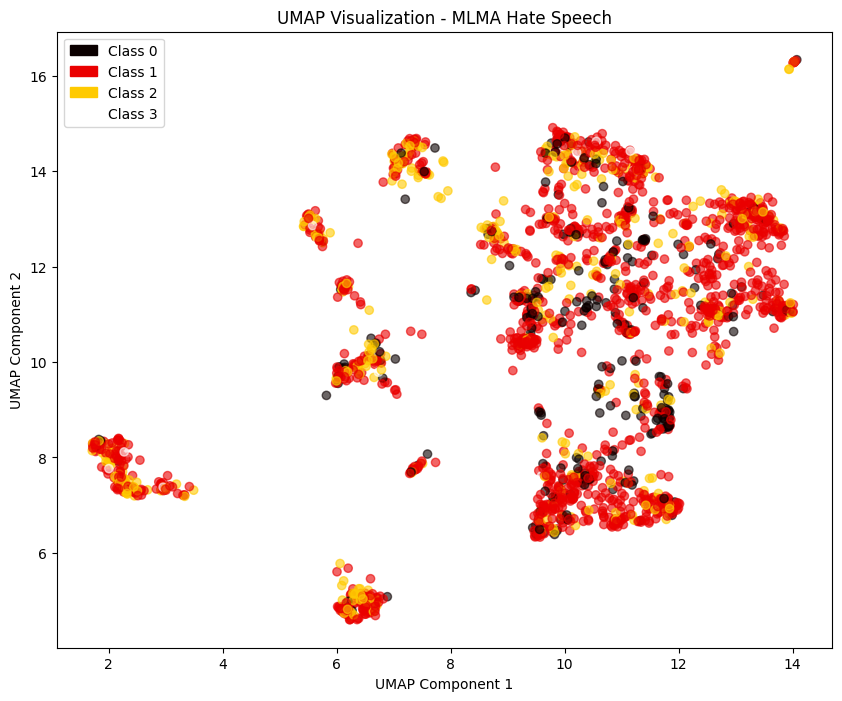

[('Decision Tree',
  'Convabuse combined',
  'NA',
  'NA',
  0.528324388789505,
  0.5259767241783131,
  0.0,
  {'dt_classifier__min_samples_split': 404,
   'dt_classifier__min_samples_leaf': 202,
   'dt_classifier__max_depth': 8,
   'dt_classifier__criterion': 'gini'},
  {0: np.float64(0.0),
   1: np.float64(0.0),
   2: np.float64(0.0),
   3: np.float64(0.0),
   4: np.float64(0.013194086374618838),
   5: np.float64(0.0),
   6: np.float64(0.0),
   7: np.float64(0.011384915504657273),
   8: np.float64(0.0),
   9: np.float64(0.0),
   10: np.float64(0.00784016792171045),
   11: np.float64(0.0),
   12: np.float64(0.0),
   13: np.float64(0.0),
   14: np.float64(0.02016347079479973),
   15: np.float64(0.008494793651039145),
   16: np.float64(0.0),
   17: np.float64(0.0),
   18: np.float64(0.0),
   19: np.float64(0.010467146824967577),
   20: np.float64(0.0),
   21: np.float64(0.0),
   22: np.float64(0.0),
   23: np.float64(0.0),
   24: np.float64(0.0),
   25: np.float64(0.0),
   26: np.float6

In [26]:
dt_classifier_model(mlma_hate_speech_target_X_train, mlma_hate_speech_target_y_train, mlma_hate_speech_target_X_test, mlma_hate_speech_target_y_test, "MLMA Hate Speech")
dt_classification_results_list

## Support Vector Machine Conclusions

In [27]:
dt_TSNE

{'Convabuse combined': array([[ 4.2794538 , -2.9065168 ],
        [ 0.609574  , -0.5042754 ],
        [ 5.6048064 , -0.11071312],
        ...,
        [-9.559273  , -3.9916425 ],
        [-1.43608   , 10.562328  ],
        [ 4.2423487 , -7.942987  ]], dtype=float32),
 'Convabuse prev_agent': array([[ -3.050156 ,   0.313419 ],
        [  5.047129 ,   2.7410321],
        [ -3.0567074,   0.3116743],
        ...,
        [ 10.490725 ,   9.94125  ],
        [-10.338742 ,  15.405203 ],
        [ 11.169895 ,   6.1161795]], dtype=float32),
 'Convabuse prev_user': array([[-2.2027872 ,  0.61049896],
        [-1.4942763 ,  0.44427148],
        [ 7.6306324 , -6.6085963 ],
        ...,
        [-4.795588  , -8.550944  ],
        [-4.3701215 ,  9.359034  ],
        [-0.31945103, -4.08745   ]], dtype=float32),
 'Convabuse agent': array([[ -2.3153524,   1.4298451],
        [  8.882892 ,   5.682214 ],
        [  3.7623508,  -0.4860353],
        ...,
        [  7.3147507,   3.9264488],
        [ -0.5255

In [28]:
dt_UMAP

{'Convabuse combined': array([[11.606882  ,  1.1595085 ],
        [ 0.2612964 ,  0.93485594],
        [19.438717  , 10.182262  ],
        ...,
        [ 3.580768  , -3.7643833 ],
        [14.956609  , 19.89605   ],
        [-2.6765797 , -9.409313  ]], dtype=float32),
 'Convabuse prev_agent': array([[-3.8708651e-01,  1.8477819e+01],
        [ 4.5722976e+00, -2.1201963e+00],
        [-1.6662600e-02,  1.8189154e+01],
        ...,
        [ 2.6160973e+01,  1.7378963e+01],
        [-1.1741642e+01, -1.5788917e+01],
        [-1.0632439e+01, -1.6088697e+00]], dtype=float32),
 'Convabuse prev_user': array([[ 5.2203116 , -0.94762075],
        [ 4.4072275 ,  1.3340636 ],
        [12.35882   ,  7.738255  ],
        ...,
        [ 2.1282501 ,  8.808111  ],
        [-6.7899685 , -8.866531  ],
        [ 8.62771   , 12.629798  ]], dtype=float32),
 'Convabuse agent': array([[-11.838433  ,  11.096924  ],
        [ -1.3202181 ,  10.970137  ],
        [ 17.920858  ,   8.368315  ],
        ...,
        [ 2

In [29]:
# Pickle both dictionaries
with open(f'{pickle_path}decision-tree-TSNE-dict_sentiment-analysis-resampled.pkl', 'wb') as f:
    pickle.dump(dt_TSNE, f)
with open(f'{pickle_path}decision-tree-UMAP-dict_sentiment-analysis-resampled.pkl', 'wb') as f:
    pickle.dump(dt_UMAP, f)

In [30]:
dt_classification_results_list

[('Decision Tree',
  'Convabuse combined',
  'NA',
  'NA',
  0.528324388789505,
  0.5259767241783131,
  0.0,
  {'dt_classifier__min_samples_split': 404,
   'dt_classifier__min_samples_leaf': 202,
   'dt_classifier__max_depth': 8,
   'dt_classifier__criterion': 'gini'},
  {0: np.float64(0.0),
   1: np.float64(0.0),
   2: np.float64(0.0),
   3: np.float64(0.0),
   4: np.float64(0.013194086374618838),
   5: np.float64(0.0),
   6: np.float64(0.0),
   7: np.float64(0.011384915504657273),
   8: np.float64(0.0),
   9: np.float64(0.0),
   10: np.float64(0.00784016792171045),
   11: np.float64(0.0),
   12: np.float64(0.0),
   13: np.float64(0.0),
   14: np.float64(0.02016347079479973),
   15: np.float64(0.008494793651039145),
   16: np.float64(0.0),
   17: np.float64(0.0),
   18: np.float64(0.0),
   19: np.float64(0.010467146824967577),
   20: np.float64(0.0),
   21: np.float64(0.0),
   22: np.float64(0.0),
   23: np.float64(0.0),
   24: np.float64(0.0),
   25: np.float64(0.0),
   26: np.float6

In [31]:
# Convert the svm_results_list to a DataFrame
dt_classification_summary = pd.DataFrame(dt_classification_results_list, columns=["Model", "Dataset", "Kernel", "Regularization", "Accuracy", "F1-score", "Ratio", "Best Parameters", "Importances", "Top 10 Importances"])
dt_classification_summary["Balance"] = "Resample"
dt_classification_summary

,Model,Dataset,Kernel,Regularization,Accuracy,F1-score,Ratio,Best Parameters,Importances,Top 10 Importances,Balance
0,Decision Tree,Convabuse combined,NA,NA,0.528324,0.525977,0.0,"{'dt_classifier__min_samples_split': 404, 'dt_...","{0: 0.0, 1: 0.0, 2: 0.0, 3: 0.0, 4: 0.01319408...","{186: 0.02760831633465277, 211: 0.028733089450...",Resample
1,Decision Tree,Convabuse prev_agent,NA,NA,0.333135,0.328530,0.0,"{'dt_classifier__min_samples_split': 404, 'dt_...","{0: 0.0, 1: 0.0, 2: 0.0, 3: 0.0, 4: 0.0, 5: 0....","{113: 0.030039031058812168, 40: 0.032907443510...",Resample
2,Decision Tree,Convabuse prev_user,NA,NA,0.430133,0.424733,0.0,"{'dt_classifier__min_samples_split': 404, 'dt_...","{0: 0.0, 1: 0.0, 2: 0.0, 3: 0.0, 4: 0.0, 5: 0....","{370: 0.031056335384902305, 49: 0.036208011727...",Resample
3,Decision Tree,Convabuse agent,NA,NA,0.350229,0.352981,0.0,"{'dt_classifier__min_samples_split': 404, 'dt_...","{0: 0.0, 1: 0.0, 2: 0.0, 3: 0.0, 4: 0.0, 5: 0....","{125: 0.02992268867269864, 167: 0.032120281950...",Resample
4,Decision Tree,Convabuse user,NA,NA,0.560127,0.556992,0.0,"{'dt_classifier__min_samples_split': 404, 'dt_...","{0: 0.0, 1: 0.0, 2: 0.0, 3: 0.0, 4: 0.0, 5: 0....","{349: 0.021045551275896513, 354: 0.02278295520...",Resample
5,Decision Tree,Dynamically Generated Hate Speech target,NA,NA,0.772140,0.672859,0.0,"{'dt_classifier__min_samples_split': 912, 'dt_...","{0: 0.0, 1: 0.0, 2: 0.0, 3: 0.0, 4: 0.0, 5: 0....","{269: 0.01757073933194338, 199: 0.019384327622...",Resample
6,Decision Tree,Dynamically Generated Hate Speech label,NA,NA,0.617027,0.616238,0.0,"{'dt_classifier__min_samples_split': 608, 'dt_...","{0: 0.0, 1: 0.005703995332370348, 2: 0.0, 3: 0...","{201: 0.020665967250452364, 312: 0.02523499817...",Resample
7,Decision Tree,MLMA Hate Speech,NA,NA,0.676848,0.546410,0.0,"{'dt_classifier__min_samples_split': 455, 'dt_...","{0: 0.0, 1: 0.0, 2: 0.0, 3: 0.0, 4: 0.0, 5: 0....","{130: 0.0, 129: 0.0, 128: 0.0, 127: 0.0, 126: ...",Resample


In [32]:
dt_classification_summary.to_csv("/content/drive/My Drive/Online MSDS/MOD C2/Political Polarization/results/sentiment_analysis_model6_dt-classification-summary_resampled.csv", index=False)